# Identifier les variables influencant les comportements des courbes de charge

But : déterminer les variables qui influent sur le comportement des courbes de charge au inter et intra régions

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from random import randint
import seaborn as sns

# Racine du projet — 2 niveaux au-dessus de ce notebook
# notebooks/03_visualisation/ -> notebooks/ -> FlexiMax/
ROOT = Path().resolve().parent.parent

DATA_RAW       = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES        = ROOT / 'reports' / 'figures'

print('Racine projet :', ROOT)
df_metadata = pd.read_parquet(DATA_PROCESSED / 'metadata_features.parquet')

Racine projet : C:\Users\eassoumou1\FlexiMax


In [138]:
df_metadata["in.ashrae_iecc_climate_zone_2004"].nunique()

17

### I. Différences et similitudes entre 3 bâtiments de la même zone ASHRAE

Filtrage de la dataframe pour ne garder que les bâtiments répondant à nos critères

In [139]:
df_metadataF = df_metadata[df_metadata['in.misc_pool']!='Has Pool']
df_metadataF = df_metadataF[df_metadataF['in.electric_vehicle_ownership']==0]
df_metadataF = df_metadataF[df_metadataF['in.has_pv']==0]
df_metadataF = df_metadataF[df_metadataF['out.electricity.heating.energy_consumption..kwh']!=0]
df_metadataF = df_metadataF[df_metadataF['out.electricity.total.energy_consumption..kwh']!=0]
df_metadataF = df_metadataF[df_metadataF['out.fuel_oil.total.energy_consumption..kwh']==0]
df_metadataF = df_metadataF[df_metadataF['out.natural_gas.total.energy_consumption..kwh']==0]
df_metadataF = df_metadataF[df_metadataF['out.propane.total.energy_consumption..kwh']==0]
df_metadataF

,bldg_id,completed_status,upgrade,in.upgrade_name,weight,applicability,in.sqft..ft2,in.representative_income,in.county_name,in.ahs_region,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
3,4,Success,0,Baseline,253.903673,True,854.0,43219.0,Lubbock County,Non-CBSA West South Central,...,0.0,0.0,0.0,11.668278,11.668278,0.0,0.0,0.0,0,1
7,8,Success,0,Baseline,253.903673,True,854.0,41362.0,Knox County,Non-CBSA East South Central,...,0.0,0.0,0.0,8.757471,8.757471,0.0,0.0,0.0,0,1
13,14,Success,0,Baseline,253.903673,True,1698.0,5484.0,Canyon County,Non-CBSA Mountain,...,0.0,0.0,0.0,12.588248,12.588248,0.0,0.0,0.2,0,3
14,15,Success,0,Baseline,253.903673,True,881.0,940.0,Duval County,Non-CBSA South Atlantic,...,0.0,0.0,0.0,21.882529,21.882529,0.0,0.0,0.2,0,4
17,18,Success,0,Baseline,253.903673,True,881.0,NaN,Cass County,Non-CBSA West South Central,...,0.0,0.0,0.0,7.701349,7.701349,0.0,0.0,0.3,8,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549938,549968,Success,0,Baseline,253.903673,True,1698.0,55156.0,Price County,Non-CBSA East North Central,...,0.0,0.0,0.0,34.424287,34.424287,0.0,0.0,0.2,0,4
549941,549971,Success,0,Baseline,253.903673,True,1138.0,53538.0,Harris County,"CBSA Houston-The Woodlands-Sugar Land, TX",...,0.0,0.0,0.0,10.416900,10.416900,0.0,0.0,0.0,0,1
549947,549977,Success,0,Baseline,253.903673,True,854.0,16241.0,Camden County,"CBSA Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",...,0.0,0.0,0.0,13.690949,13.690949,0.0,0.0,NaN,0,0
549966,549996,Success,0,Baseline,253.903673,True,872.0,15234.0,Story County,Non-CBSA West North Central,...,0.0,0.0,0.0,23.041369,23.041369,0.0,0.0,0.2,0,4


Téléchargement de 3 bâtiments répondant aux critères par zone

In [140]:
ASHRAE_zones = df_metadataF["in.ashrae_iecc_climate_zone_2004"].sort_values().unique()
ASHRAE_zones

<ArrowStringArray>
[ '1A',  '2A',  '2B',  '3A',  '3B',  '3C',  '4A',  '4B',  '4C',  '5A',  '5B',
  '6A',  '6B',  '7A', '7AK',  '7B']
Length: 16, dtype: str

In [141]:
df_single_zone = df_metadataF[df_metadataF["in.ashrae_iecc_climate_zone_2004"]=="1A"].reset_index(drop=True)
df_single_zone

,bldg_id,completed_status,upgrade,in.upgrade_name,weight,applicability,in.sqft..ft2,in.representative_income,in.county_name,in.ahs_region,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
0,88,Success,0,Baseline,253.903673,True,1207.0,94001.0,Broward County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,8.456084,8.456084,0.0,0.0,NaN,0,0
1,252,Success,0,Baseline,253.903673,True,1138.0,33212.0,Broward County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,5.836956,5.836956,0.0,0.0,0.0,0,1
2,337,Success,0,Baseline,253.903673,True,1228.0,54945.0,Broward County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,16.327018,16.327018,0.0,0.0,0.1,0,4
3,361,Success,0,Baseline,253.903673,True,1682.0,NaN,Miami-Dade County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,1.067915,1.067915,0.0,0.0,0.0,0,1
4,383,Success,0,Baseline,253.903673,True,1698.0,10805.0,Miami-Dade County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,9.113854,9.113854,0.0,0.0,0.2,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4323,549399,Success,0,Baseline,253.903673,True,1207.0,39718.0,Miami-Dade County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,8.629207,8.629207,0.0,0.0,0.0,0,1
4324,549620,Success,0,Baseline,253.903673,True,1698.0,93068.0,Broward County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,6.021765,6.021765,0.0,0.0,0.1,4,6
4325,549640,Success,0,Baseline,253.903673,True,854.0,32204.0,Miami-Dade County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,5.771510,5.771510,0.0,0.0,0.0,0,1
4326,549800,Success,0,Baseline,253.903673,True,1138.0,33494.0,Broward County,"CBSA Miami-Fort Lauderdale-West Palm Beach, FL",...,0.0,0.0,0.0,6.059206,6.059206,0.0,0.0,0.0,0,1


In [142]:
# Télecharger les séries temporelles par bâtiment depuis le data lake public OEDI (ResStock 2025, AMY2018)

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_RAW       = ROOT / 'data' / 'raw'

OEDI_BASE = (
    'https://oedi-data-lake.s3.amazonaws.com/'
    'nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock/'
    '2025/resstock_amy2018_release_1/'
    'timeseries_individual_buildings/by_state/upgrade=0'
)

def download_timeseries(bldg_id: int, state: str, save: bool = True) -> pd.DataFrame:
    out = DATA_RAW / f'{bldg_id}-0.parquet'
    if out.exists():    #si le fichier existe déjà on charge localement sans retélécharger
        print(f'Fichier existant trouvé, chargement local : {out}')
        df = pd.read_parquet(out)
    else:
        url = f'{OEDI_BASE}/state={state}/{bldg_id}-0.parquet'
        print(f'Téléchargement : {url}')
        df = pd.read_parquet(url)
        if save:
            #out.parent.mkdir(parents=True, exist_ok=True) 
            df.to_parquet(out)
            print(f'Sauvegardé : {out}')
    print(f'Shape : {df.shape} | {df["timestamp"].iloc[0]} → {df["timestamp"].iloc[-1]}')
    return df

In [143]:
df_zone = df_metadataF[df_metadataF["in.ashrae_iecc_climate_zone_2004"]=="3A"].reset_index(drop=True)

random_index = randint(0,df_zone.shape[0])
chosen_building = (df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)
print(chosen_building)

(np.int64(421565), 'TX', True)


            Attention : cette prochaine cellule télécharge 51 fichiers
            Enlever les guillemets pour l'executer (2min23sec)

In [144]:
#A ne pas executer (les valeurs aléatoires générées par ce code sont téléchargeables dans les cellules en dessous)
"""dataframes = []
acc_zones = 0
acc_df = 0
for e in ASHRAE_zones :
    df_zone = df_metadataF[df_metadataF["in.ashrae_iecc_climate_zone_2004"]==e].reset_index(drop=True)
    acc_zones +=1
    for i in range(3):
        random_index = randint(0,df_zone.shape[0])
        df_dwnld = download_timeseries(df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)
        dataframes.append(df_dwnld)
        acc_df += 1"""


'dataframes = []\nacc_zones = 0\nacc_df = 0\nfor e in ASHRAE_zones :\n    df_zone = df_metadataF[df_metadataF["in.ashrae_iecc_climate_zone_2004"]==e].reset_index(drop=True)\n    acc_zones +=1\n    for i in range(3):\n        random_index = randint(0,df_zone.shape[0])\n        df_dwnld = download_timeseries(df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)\n        dataframes.append(df_dwnld)\n        acc_df += 1'

In [145]:
"""print("Nombre de dataframes téléchargés : "+str(acc_df))
print("Nombre de zones différentes téléchargées : "+str(acc_zones))"""

'print("Nombre de dataframes téléchargés : "+str(acc_df))\nprint("Nombre de zones différentes téléchargées : "+str(acc_zones))'

In [146]:
""""data = []
for i in range(len(dataframes)):
    data.append(int(dataframes[i]["bldg_id"][0]))
data1=[]
for e in data :
    data1.append(df_metadataF["in.state"].loc[df_metadataF["bldg_id"]==e].iloc[0])
print(data)
print(data1)"""

'"data = []\nfor i in range(len(dataframes)):\n    data.append(int(dataframes[i]["bldg_id"][0]))\ndata1=[]\nfor e in data :\n    data1.append(df_metadataF["in.state"].loc[df_metadataF["bldg_id"]==e].iloc[0])\nprint(data)\nprint(data1)'

In [147]:
dataframes_ids = [4484, 380471, 91464, 534285, 458117, 122574, 380408, 520065, 395953, 265615, 83173, 110580, 419336, 105641, 546938, 126632, 428085, 314129, 539366, 35316, 191012, 359603, 321275, 394731, 225158, 37829, 471071, 254822, 545279, 255950, 540636, 446655, 457230, 425687, 86564, 294853, 476927, 133656, 163783, 138561, 458603, 90903, 63176, 412985, 40129, 246313, 52135, 424702]
dataframes_states = ['FL', 'FL', 'FL', 'FL', 'FL', 'FL', 'AZ', 'AZ', 'AZ', 'GA', 'MS', 'OK', 'NV', 'CA', 'CA', 'CA', 'CA', 'CA', 'TN', 'KY', 'WV', 'NM', 'NM', 'NM', 'WA', 'OR', 'WA', 'IA', 'CT', 'OH', 'AZ', 'ID', 'NV', 'MN', 'NY', 'SD', 'WA', 'MT', 'MT', 'MN', 'MN', 'ND', 'AK', 'AK', 'AK', 'CO', 'CO', 'CO']

In [148]:
out = DATA_RAW / f'{4484}-0.parquet'
out.exists()

True

In [149]:
dataframes = []
for i in range(len(dataframes_ids)):
    df_dwnld = download_timeseries(dataframes_ids[i], dataframes_states[i])
    dataframes.append(df_dwnld)

dataframes[0].head(10)

Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\4484-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\380471-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\91464-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\534285-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\458117-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\122574-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant tr

,bldg_id,timestamp,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,...,out.schedules.lighting_interior,out.schedules.no_space_cooling,out.schedules.no_space_heating,out.schedules.occupants,out.schedules.peak_period,out.schedules.plug_loads_other,out.schedules.plug_loads_tv,out.schedules.power_outage,out.schedules.pre_peak_period,out.schedules.vacancy
0,4484,2018-01-01 00:15:00,854.0,0.00394,0.0,0.0,0.01099,0.00002,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
1,4484,2018-01-01 00:30:00,854.0,0.00394,0.0,0.0,0.00971,0.00002,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
2,4484,2018-01-01 00:45:00,854.0,0.00394,0.0,0.0,0.00846,0.00002,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
3,4484,2018-01-01 01:00:00,854.0,0.00394,0.0,0.0,0.00737,0.00002,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
4,4484,2018-01-01 01:15:00,854.0,0.00394,0.0,0.0,0.30919,0.01130,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
5,4484,2018-01-01 01:30:00,854.0,0.00394,0.0,0.0,0.02907,0.00007,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
6,4484,2018-01-01 01:45:00,854.0,0.00394,0.0,0.0,0.02634,0.00006,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
7,4484,2018-01-01 02:00:00,854.0,0.00394,0.0,0.0,0.05994,0.00017,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
8,4484,2018-01-01 02:15:00,854.0,0.00394,0.0,0.0,0.04172,0.00011,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0
9,4484,2018-01-01 02:30:00,854.0,0.00394,0.0,0.0,0.03796,0.00010,0.0,0.0,...,0.0495,0.0,0.0,1.0,NaN,0.562,0.0159,0.0,NaN,0.0


Visualisation des courbes de charge par zone ASHRAE

            Chaque groupe de 3 bâtiments dans dataframes appartient à une même zone, dans l'ordre de ASHRAE_zones

In [150]:
ASHRAE_zones

<ArrowStringArray>
[ '1A',  '2A',  '2B',  '3A',  '3B',  '3C',  '4A',  '4B',  '4C',  '5A',  '5B',
  '6A',  '6B',  '7A', '7AK',  '7B']
Length: 16, dtype: str

In [151]:
for i in range(3):
    if df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]=="1A"].loc[df_metadata["bldg_id"]==dataframes[i]["bldg_id"].iloc[0]].size != 0:
        print("Correct zone 1A")
    else:
        print("Wrong zones")

Correct zone 1A
Correct zone 1A
Correct zone 1A


In [152]:
for i in range(len(ASHRAE_zones)*3):
    dataframes[i]["minute"] = dataframes[i]["timestamp"].dt.minute + dataframes[i]["timestamp"].dt.hour*60
    dataframes[i]["date"] = dataframes[i]["timestamp"].dt.date


In [261]:
def make_3_curb_emission_plot(a,b,c):
    df0 = dataframes[a].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
    df1 = dataframes[b].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
    df2 = dataframes[c].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

    plt.figure(figsize=(8,5))

    plt.plot(df0.index, df0.values, marker=".", color='darkblue', label="Building "+str(dataframes[a]["bldg_id"].loc[3]))
    plt.plot(df1.index, df1.values, marker=".", color='darkred', label="Building "+str(dataframes[b]["bldg_id"].loc[3]))
    plt.plot(df2.index, df2.values, marker=".", color='darkgreen', label="Building "+str(dataframes[c]["bldg_id"].loc[3]))

    plt.xlabel("Time of Day (Minutes, 1440min=24h)")
    plt.ylabel("Electricity Consumption (kWh)")
    plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,2.5])

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    return

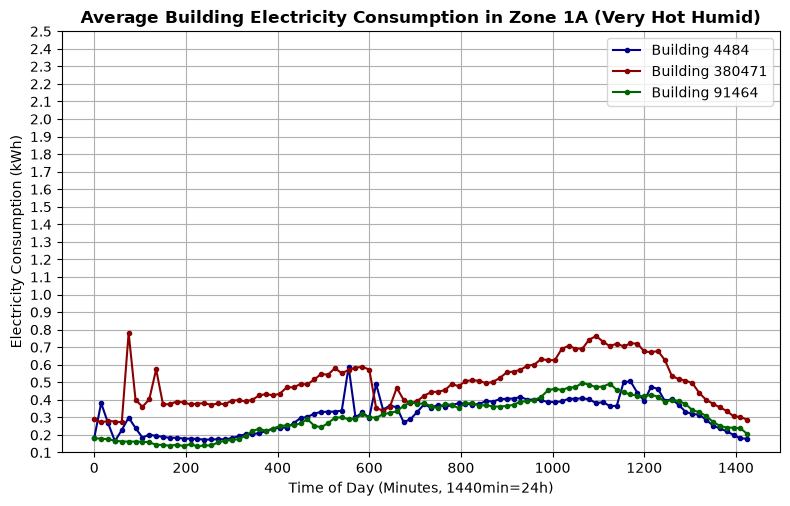

In [262]:
make_3_curb_emission_plot(0,1,2)
plt.title('Average Building Electricity Consumption in Zone 1A (Very Hot Humid)', fontsize=12, fontweight='bold')
plt.show()

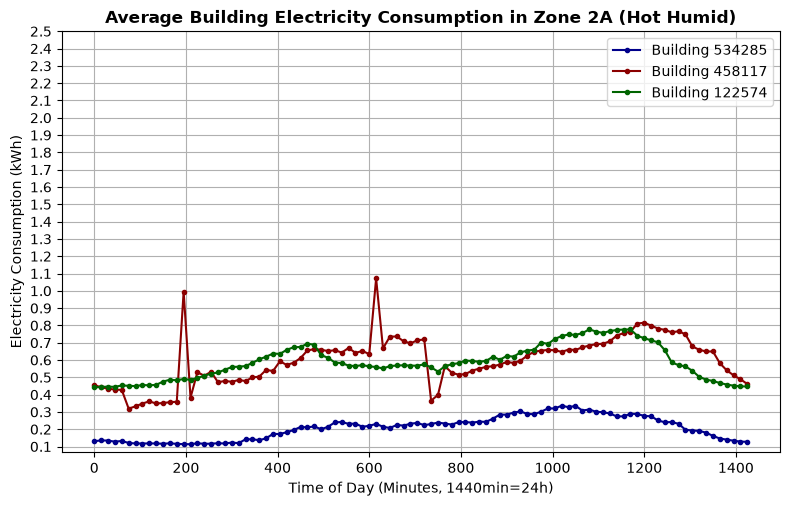

In [263]:
make_3_curb_emission_plot(3,4,5)
plt.title('Average Building Electricity Consumption in Zone 2A (Hot Humid)', fontsize=12, fontweight='bold')
plt.show()

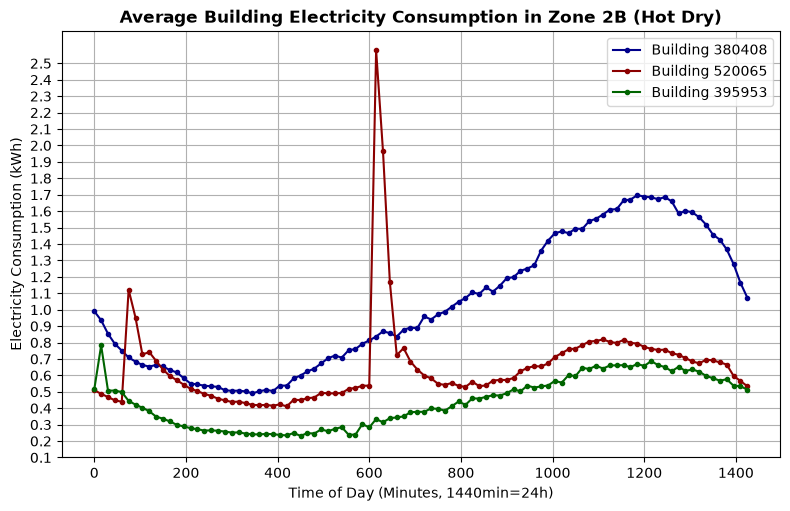

In [264]:
make_3_curb_emission_plot(6,7,8)
plt.title('Average Building Electricity Consumption in Zone 2B (Hot Dry)', fontsize=12, fontweight='bold')
plt.show()

In [265]:
ASHRAE_zones

<ArrowStringArray>
[ '1A',  '2A',  '2B',  '3A',  '3B',  '3C',  '4A',  '4B',  '4C',  '5A',  '5B',
  '6A',  '6B',  '7A', '7AK',  '7B']
Length: 16, dtype: str

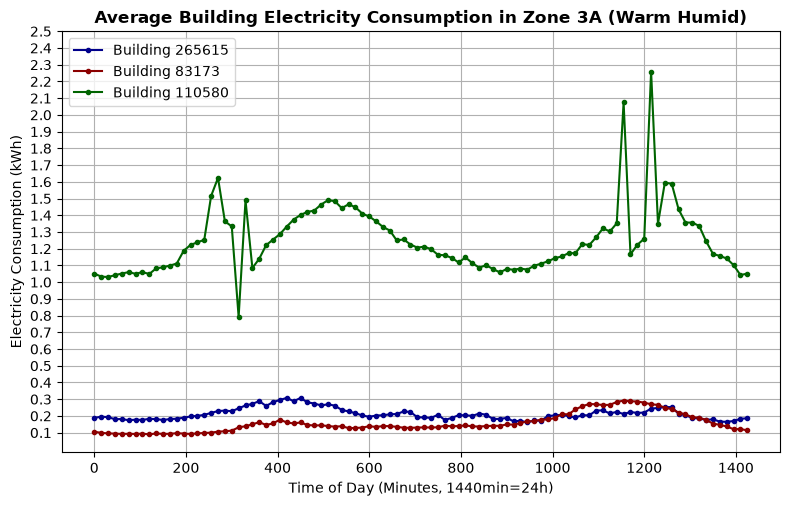

In [266]:
make_3_curb_emission_plot(9,10,11)
plt.title('Average Building Electricity Consumption in Zone 3A (Warm Humid)', fontsize=12, fontweight='bold')
plt.show()

In [267]:
print("EMISSION DIFFERENCE :")
print ("Household 110580 maximum : "+ str(dataframes[11].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max()))
print ("Household 265615 maximum : "+ str(dataframes[9].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max()))
print("Household 83173 maximum : "+str(dataframes[10].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max()))
print("At it's maximum, household 110580 consumes "+ str(dataframes[11].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max()/dataframes[9].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max())+" times more than household 265615")
print("\n")
print("HOUSEHOLD INCOME : ")
print("Household 110580 : "+str(df_metadataF["in.income"].loc[df_metadataF["bldg_id"]==110580].iloc[0]))
print("Household 265615 : "+str(df_metadataF["in.income"].loc[df_metadataF["bldg_id"]==265615].iloc[0]))
print("Household 83173 : "+str(df_metadataF["in.income"].loc[df_metadataF["bldg_id"]==83173].iloc[0]))
print("--> Household 110580 earns "+str(df_metadataF["in.income"].loc[df_metadataF["bldg_id"]==110580].iloc[0]/df_metadataF["in.income"].loc[df_metadataF["bldg_id"]==265615].iloc[0])+" times more than houselhold 265615")
print("\n")
print("NUMBER OF OCCUPANTS :")
print("Household 110580 : "+str(df_metadataF["in.occupants"].loc[df_metadataF["bldg_id"]==110580].iloc[0]))
print("Household 265615 : "+str(df_metadataF["in.occupants"].loc[df_metadataF["bldg_id"]==265615].iloc[0]))
print("Household 83173 : "+str(df_metadataF["in.occupants"].loc[df_metadataF["bldg_id"]==83173].iloc[0]))
print("\n")

EMISSION DIFFERENCE :
Household 110580 maximum : 2.2584896
Household 265615 maximum : 0.3079371
Household 83173 maximum : 0.29180667
At it's maximum, household 110580 consumes 7.3342566 times more than household 265615


HOUSEHOLD INCOME : 
Household 110580 : 200000.0
Household 265615 : 200000.0
Household 83173 : 5000.0
--> Household 110580 earns 1.0 times more than houselhold 265615


NUMBER OF OCCUPANTS :
Household 110580 : 4.0
Household 265615 : 2.0
Household 83173 : 1.0




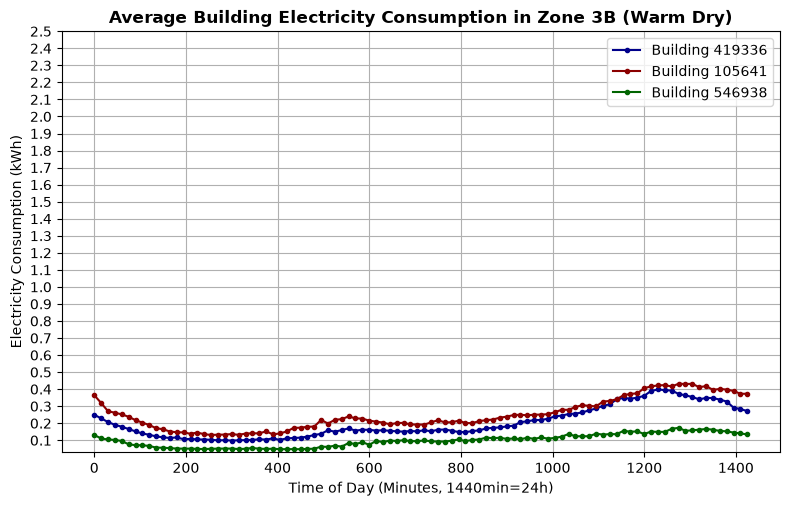

In [268]:
make_3_curb_emission_plot(12,13,14)
plt.title('Average Building Electricity Consumption in Zone 3B (Warm Dry)', fontsize=12, fontweight='bold')
plt.show()

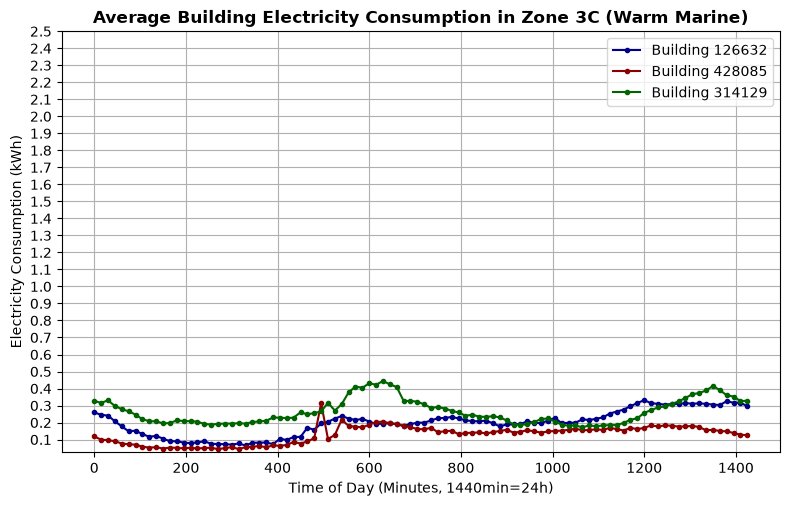

In [269]:
make_3_curb_emission_plot(15,16,17)
plt.title('Average Building Electricity Consumption in Zone 3C (Warm Marine)', fontsize=12, fontweight='bold')
plt.show()

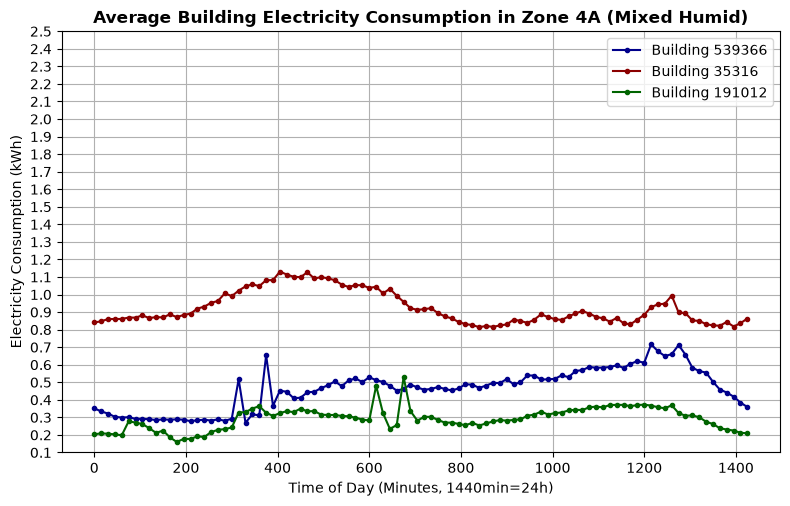

In [270]:
make_3_curb_emission_plot(18,19,20)
plt.title('Average Building Electricity Consumption in Zone 4A (Mixed Humid)', fontsize=12, fontweight='bold')
plt.show()

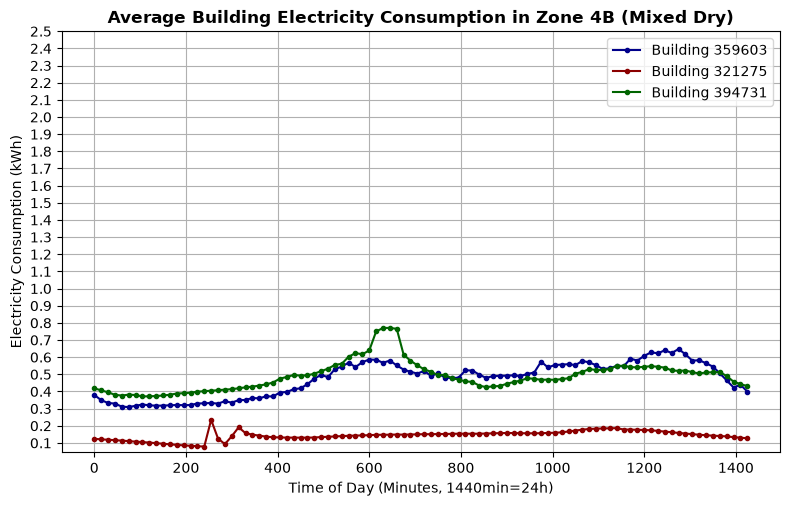

In [271]:
make_3_curb_emission_plot(21,22,23)
plt.title('Average Building Electricity Consumption in Zone 4B (Mixed Dry)', fontsize=12, fontweight='bold')
plt.show()

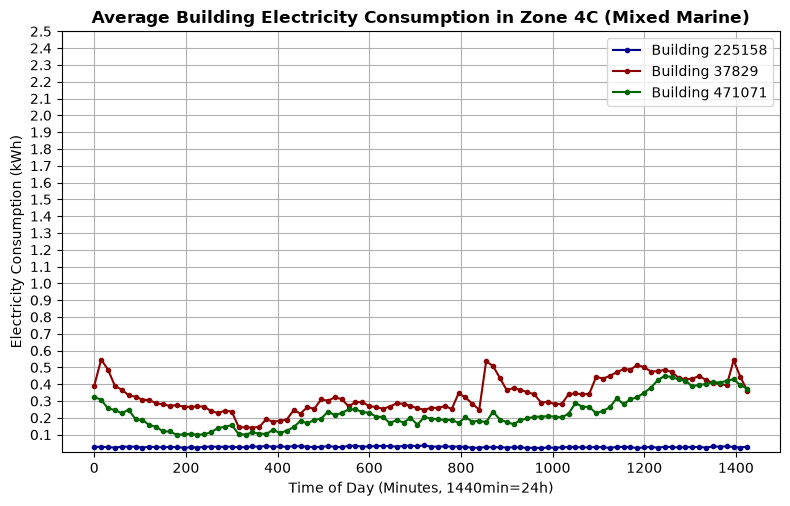

In [272]:
make_3_curb_emission_plot(24,25,26)
plt.title('Average Building Electricity Consumption in Zone 4C (Mixed Marine)', fontsize=12, fontweight='bold')
plt.show()

In [273]:
#On vérifie que la courbe bleue n'est pas vide
df_metadata["in.occupants"].loc[df_metadata["bldg_id"]==221745].iloc[0]

np.float64(2.0)

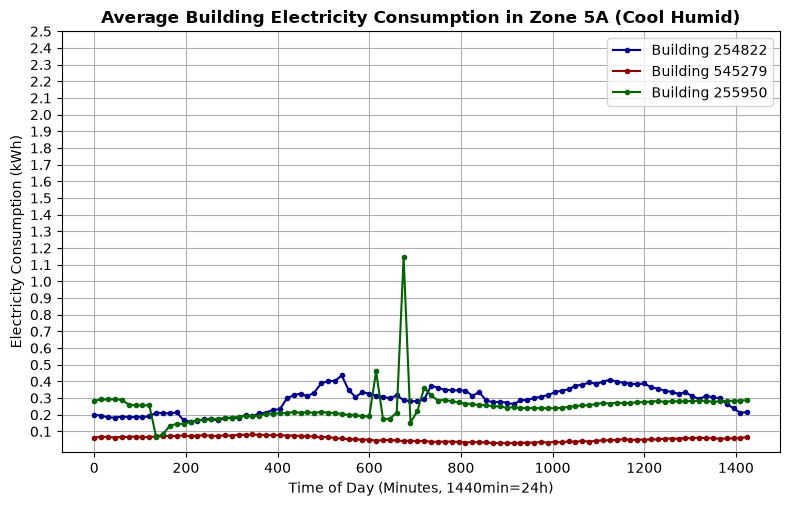

In [274]:
make_3_curb_emission_plot(27,28,29)
plt.title('Average Building Electricity Consumption in Zone 5A (Cool Humid)', fontsize=12, fontweight='bold')
plt.show()

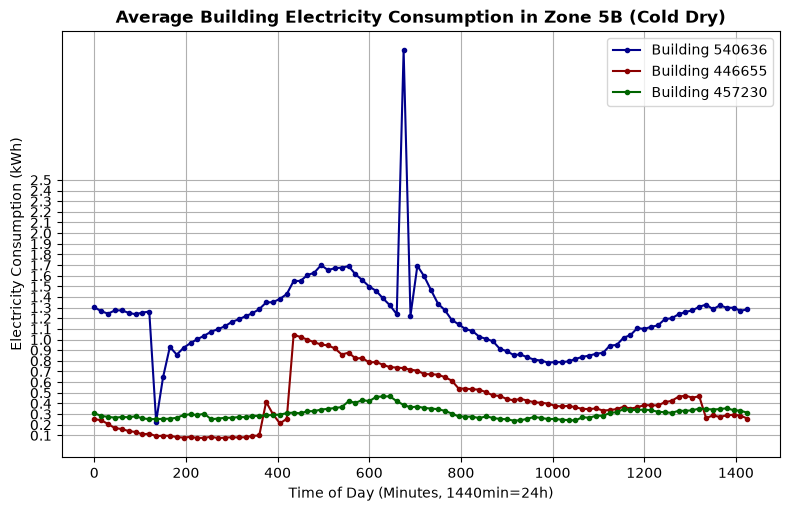

In [275]:
make_3_curb_emission_plot(30,31,32)
plt.title('Average Building Electricity Consumption in Zone 5B (Cold Dry)', fontsize=12, fontweight='bold')
plt.show()

In [287]:
df30 = dataframes[30].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
df30[df30==df30.max()]
#PIC A 11H15

minute
675    3.717005
Name: out.electricity.total.energy_consumption..kwh, dtype: float32

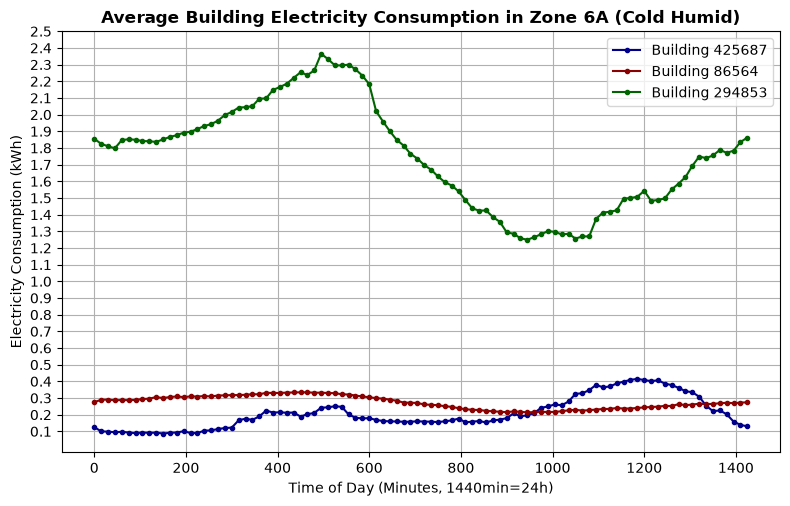

In [276]:
make_3_curb_emission_plot(33,34,35)
plt.title('Average Building Electricity Consumption in Zone 6A (Cold Humid)', fontsize=12, fontweight='bold')
plt.show()

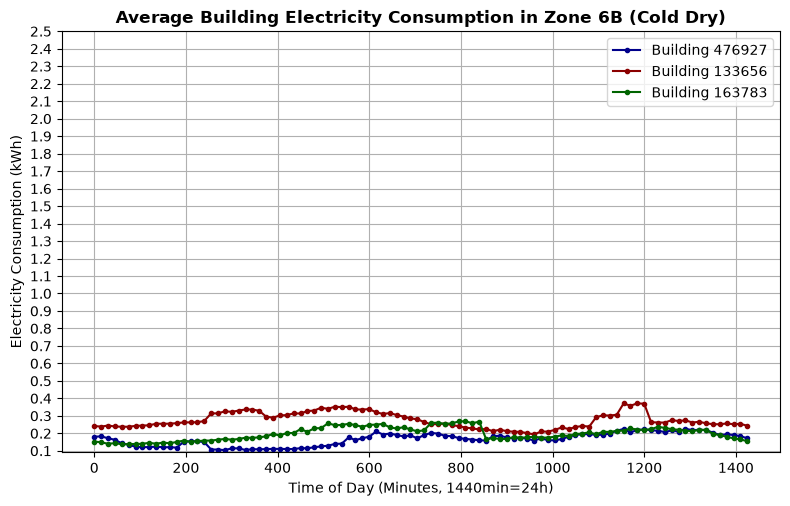

In [277]:
make_3_curb_emission_plot(36,37,38)
plt.title('Average Building Electricity Consumption in Zone 6B (Cold Dry)', fontsize=12, fontweight='bold')
plt.show()

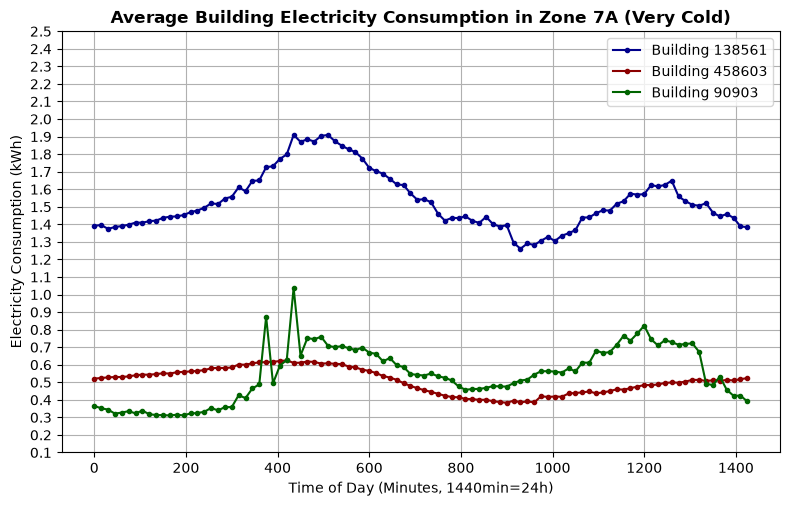

In [278]:
make_3_curb_emission_plot(39,40,41)
plt.title('Average Building Electricity Consumption in Zone 7A (Very Cold)', fontsize=12, fontweight='bold')
plt.show()

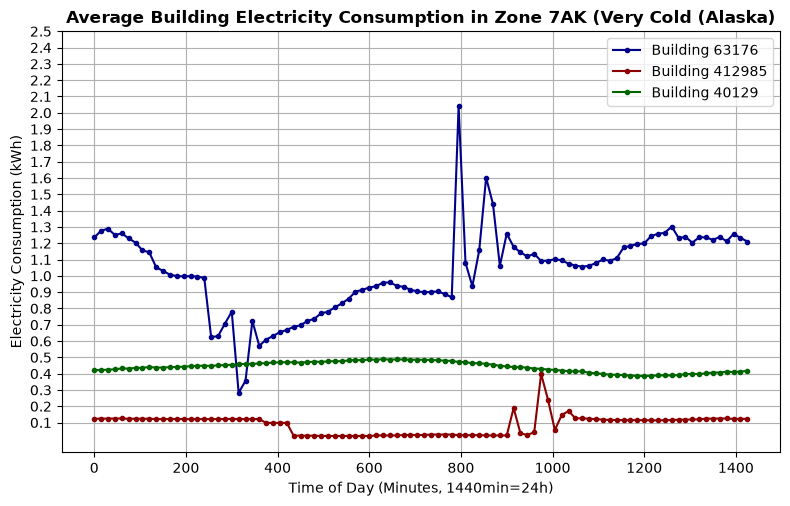

In [279]:
make_3_curb_emission_plot(42,43,44)
plt.title('Average Building Electricity Consumption in Zone 7AK (Very Cold (Alaska)', fontsize=12, fontweight='bold')
plt.show()

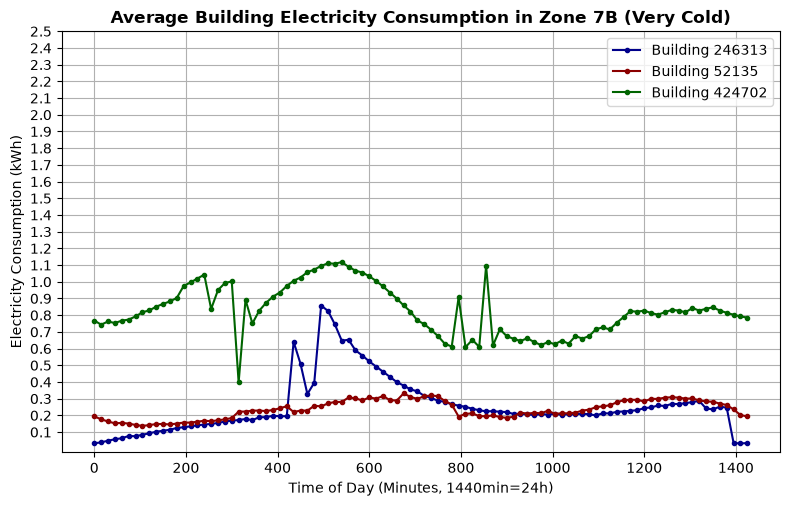

In [280]:
make_3_curb_emission_plot(45,46,47)
plt.title('Average Building Electricity Consumption in Zone 7B (Very Cold)', fontsize=12, fontweight='bold')
plt.show()

### Analyse des variables explicatives des 3 courbes par une courbe monotone décroissante

In [174]:
APPLIANCES = [
'out.schedules.ceiling_fan',
'out.schedules.clothes_dryer',
'out.schedules.clothes_washer',
'out.schedules.cooking_range',
'out.schedules.dishwasher',
'out.schedules.hot_water_dishwasher',
'out.schedules.hot_water_fixtures',
'out.schedules.lighting_interior',
'out.schedules.plug_loads_other',
'out.schedules.plug_loads_tv'
]

In [175]:
def make_mono_plot(index):
    df_app = dataframes[index].copy(deep=True)
    
    for col in df_app.columns.copy():
        if col not in APPLIANCES and col != 'minute' and col != "out.electricity.total.energy_consumption..kwh":
            df_app.drop(columns=col, inplace=True)
        elif pd.isna(df_app[col].iloc[0]):
            df_app.drop(columns=col, inplace=True)

    df_app = df_app.groupby("minute", as_index=False).mean()
    df_app["Total"] = df_app.drop(columns=["minute","out.electricity.total.energy_consumption..kwh"]).sum(axis=1)
    df_app = df_app.sort_values(by="Total", ascending=False).reset_index(drop=True)
    plot_cols = [col for col in df_app.columns if col not in ["minute", "Total", "out.electricity.total.energy_consumption..kwh"]]

    if not plot_cols:
            print(f"Aucune variable à tracer pour le dataframe {index}")
            return
    
    x = range(len(df_app))
    y = [df_app[col].values for col in plot_cols]
    names = [col[14:] for col in plot_cols]

    plt.figure(figsize=(8, 4))
    plt.stackplot(x, *y, labels=names)
    plt.title("Load Intensity per Day (Monotonic Decreasing)")
    plt.xlabel("Sorted minuts")
    plt.ylabel("Consumption (kWh)")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

1A

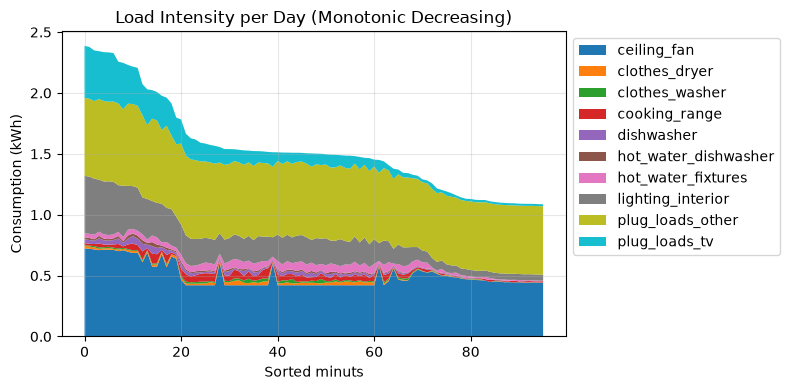

In [176]:
make_mono_plot(0)

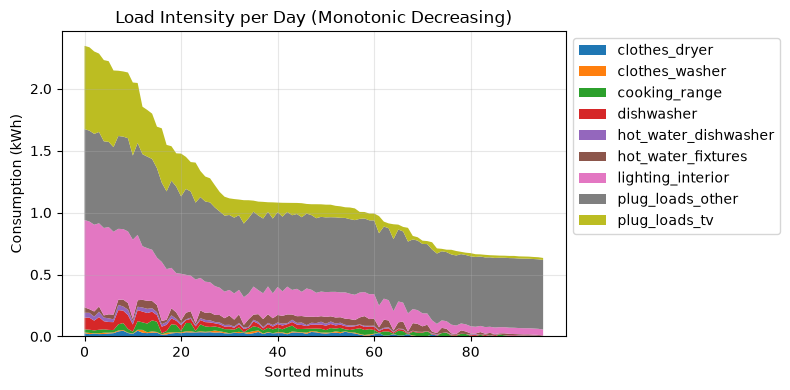

In [177]:
make_mono_plot(1)

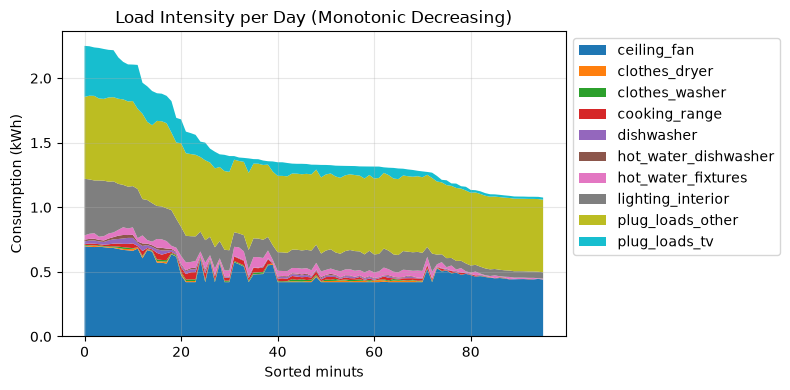

In [178]:
make_mono_plot(2)

2A

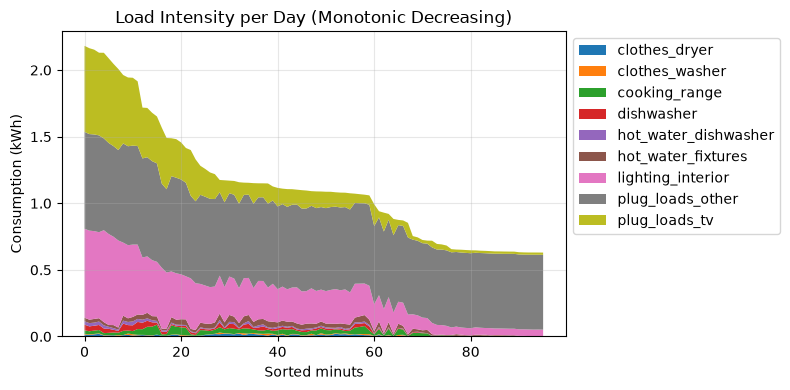

In [179]:
make_mono_plot(3)

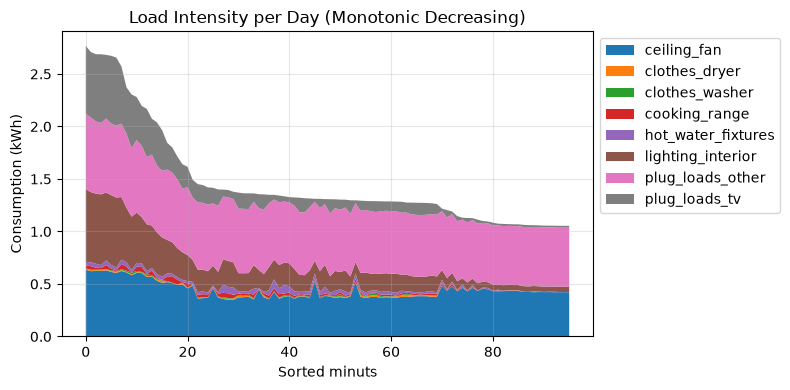

In [180]:
make_mono_plot(4)

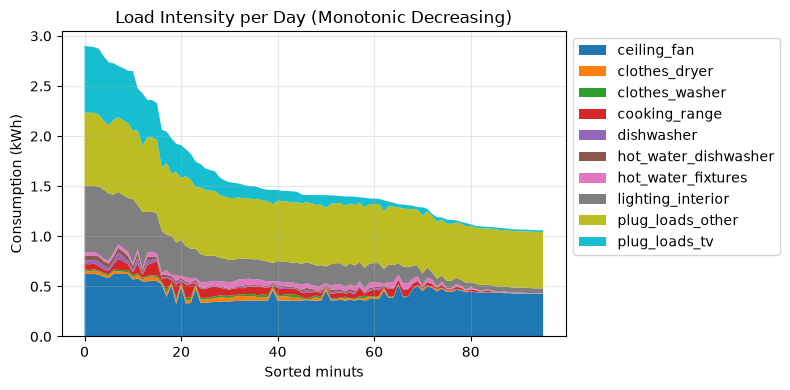

In [181]:
make_mono_plot(5)

2B

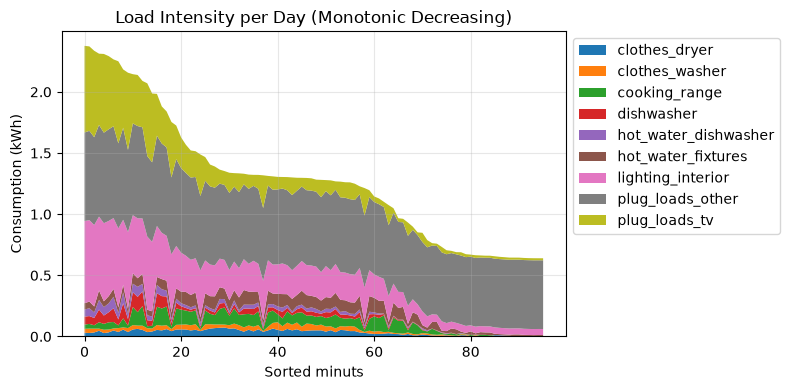

In [182]:
make_mono_plot(6)

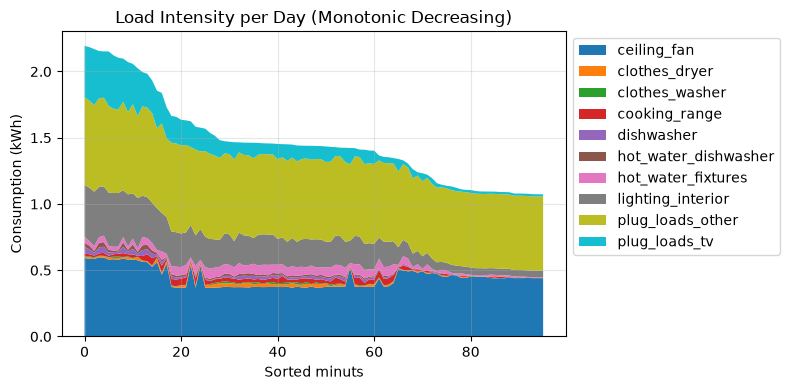

In [183]:
make_mono_plot(7)

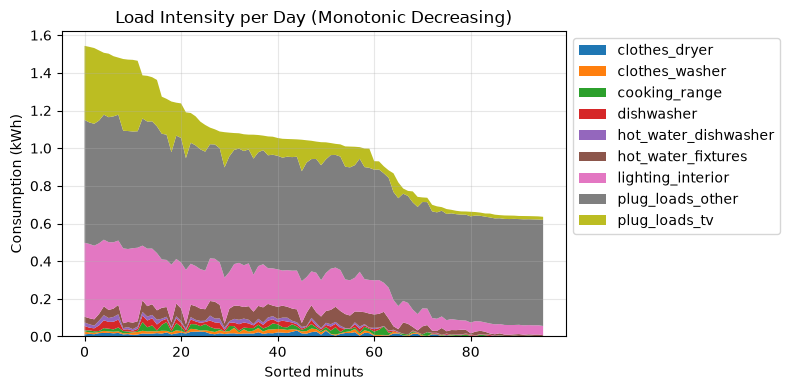

In [184]:
make_mono_plot(8)

3A

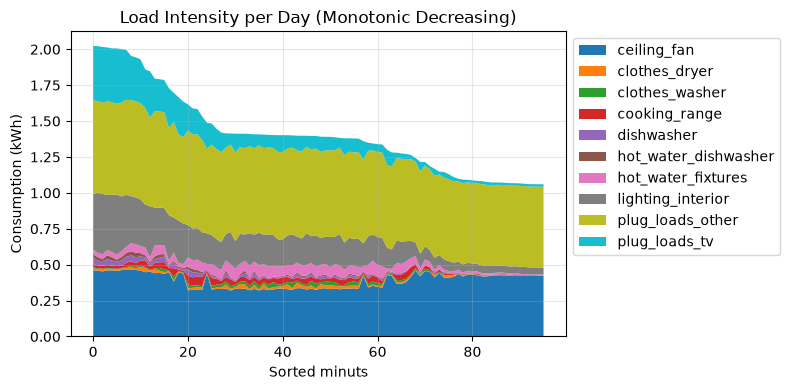

In [185]:
make_mono_plot(9)

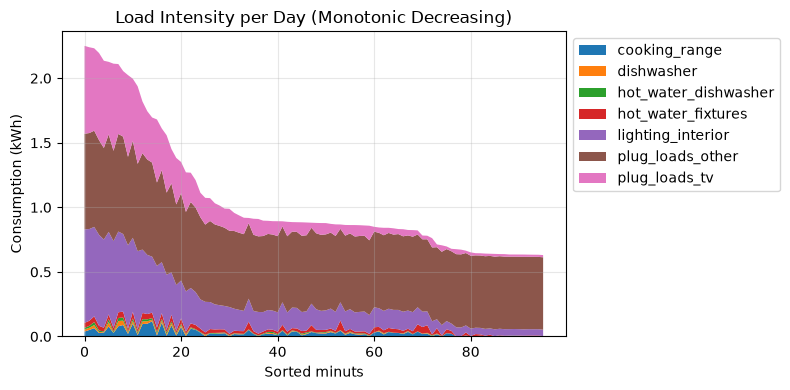

In [186]:
make_mono_plot(10)

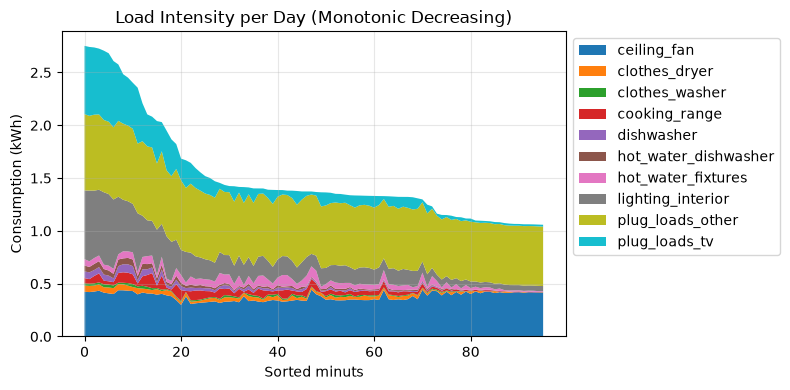

In [187]:
make_mono_plot(11)

3B

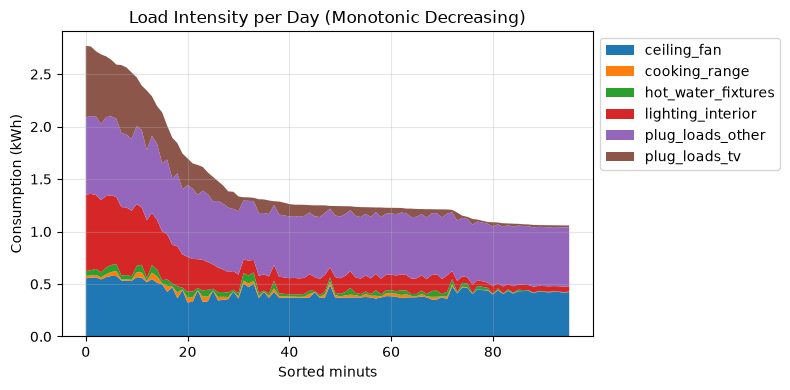

In [188]:
make_mono_plot(12)

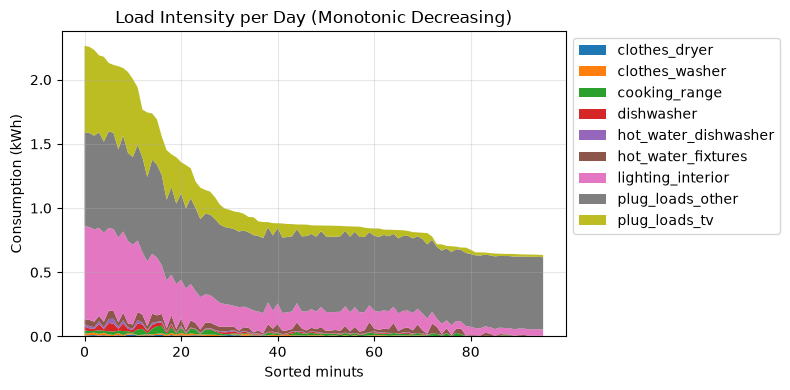

In [189]:
make_mono_plot(13)

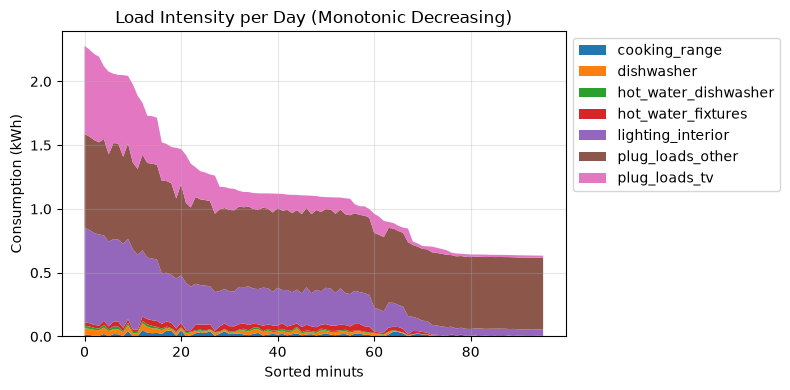

In [190]:
make_mono_plot(14)

3C

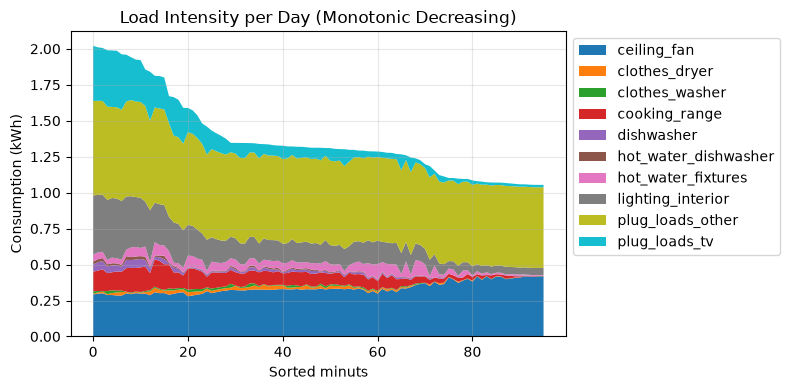

In [191]:
make_mono_plot(15)

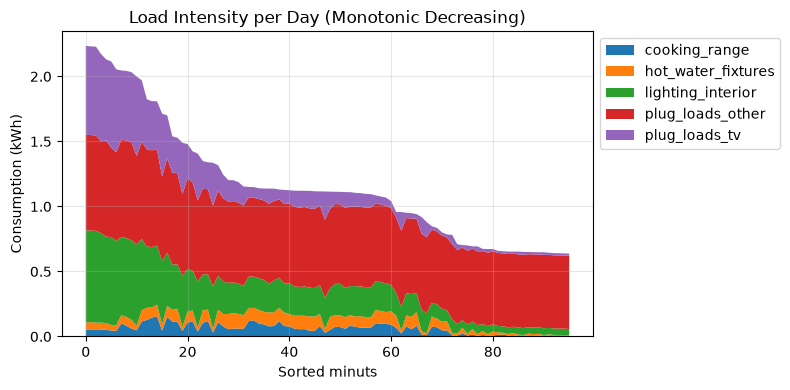

In [192]:
make_mono_plot(16)

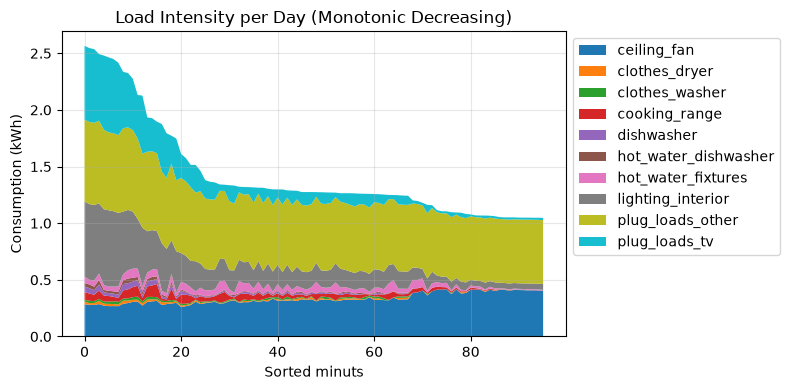

In [193]:
make_mono_plot(17)

4A

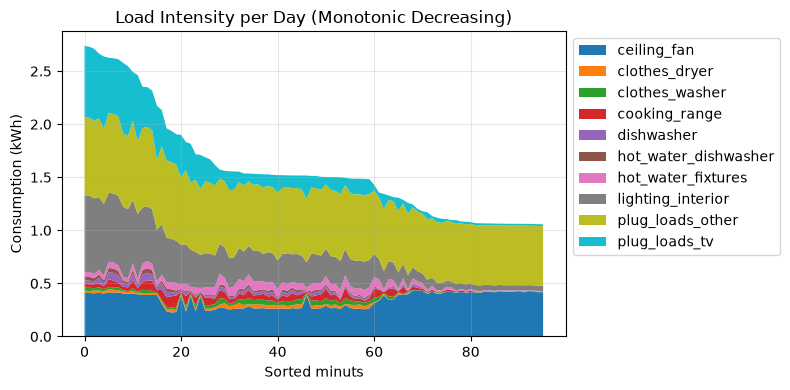

In [194]:
make_mono_plot(18)

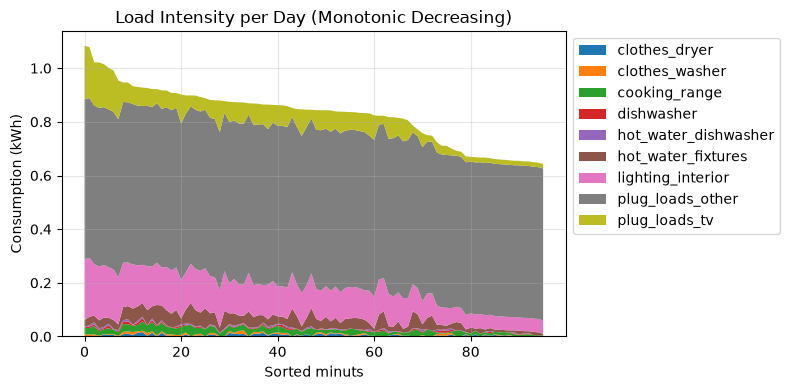

In [195]:
make_mono_plot(19)

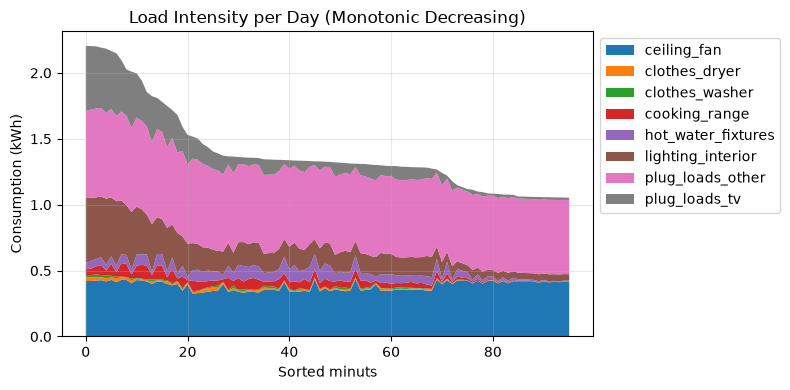

In [196]:
make_mono_plot(20)

4B

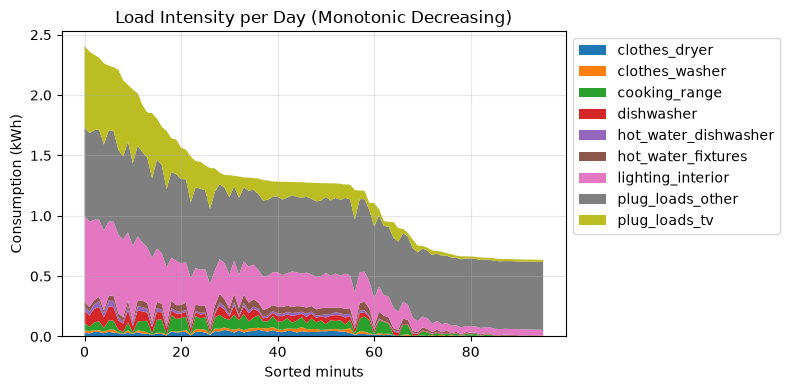

In [197]:
make_mono_plot(21)

In [198]:
make_mono_plot(22)

Aucune variable à tracer pour le dataframe 22


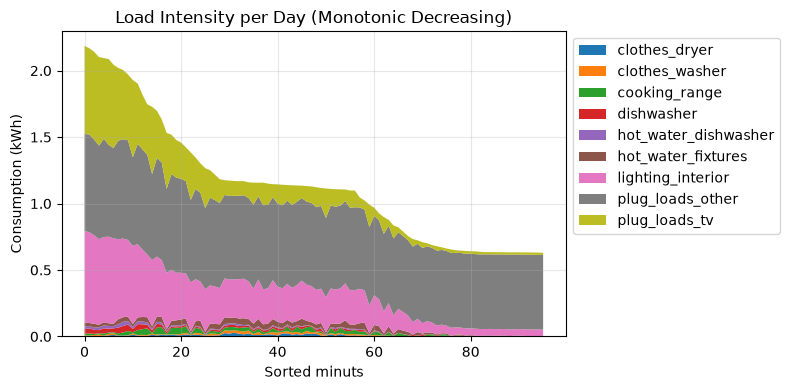

In [199]:
make_mono_plot(23)

4C

In [200]:
make_mono_plot(24)

Aucune variable à tracer pour le dataframe 24


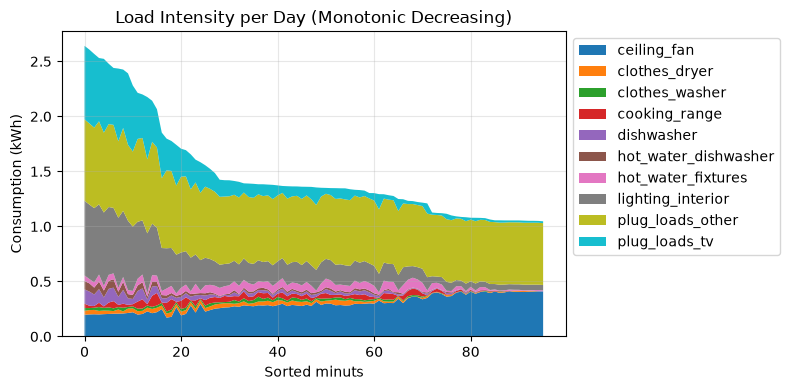

In [201]:
make_mono_plot(25)

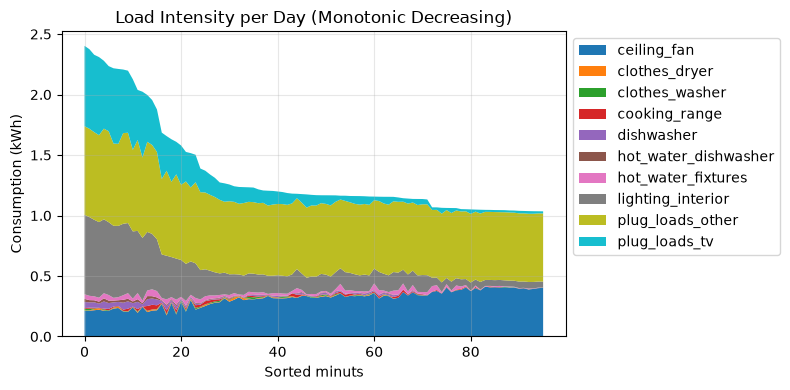

In [202]:
make_mono_plot(26)

5A

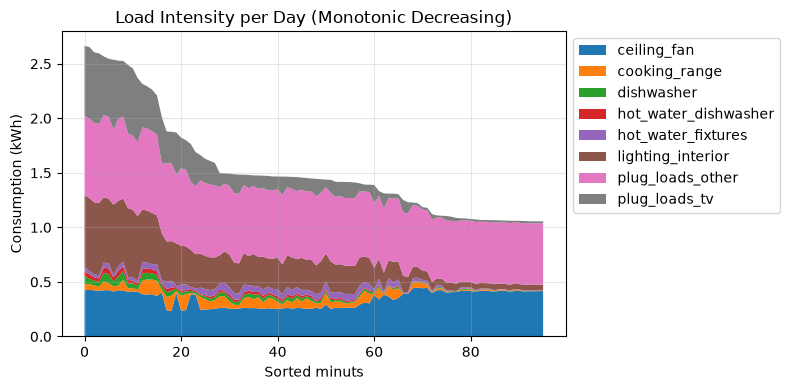

In [203]:
make_mono_plot(27)

In [204]:
make_mono_plot(28)

Aucune variable à tracer pour le dataframe 28


In [205]:
make_mono_plot(29)

Aucune variable à tracer pour le dataframe 29


5B

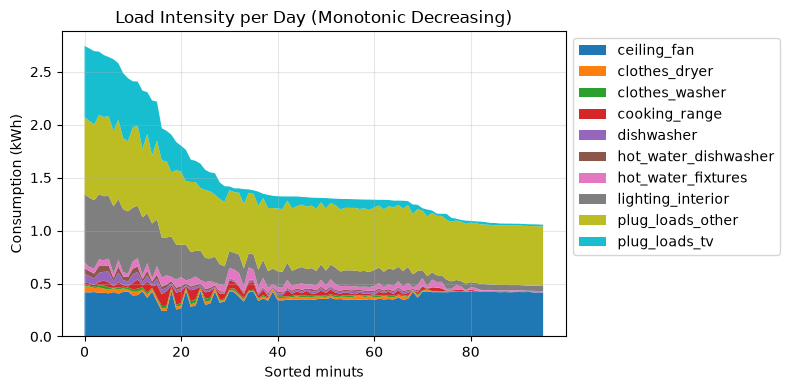

In [206]:
make_mono_plot(30)

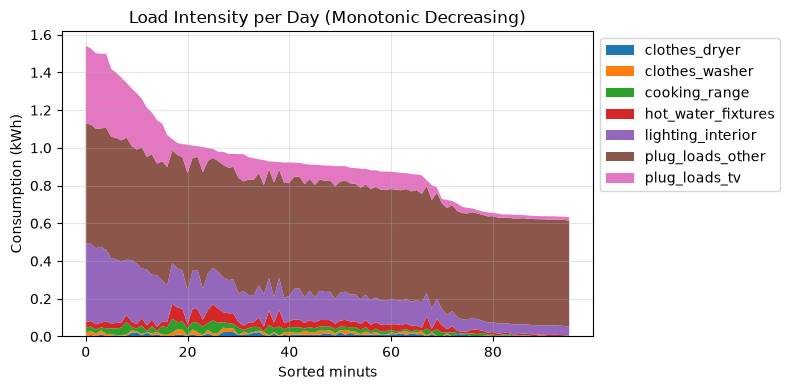

In [207]:
make_mono_plot(31)

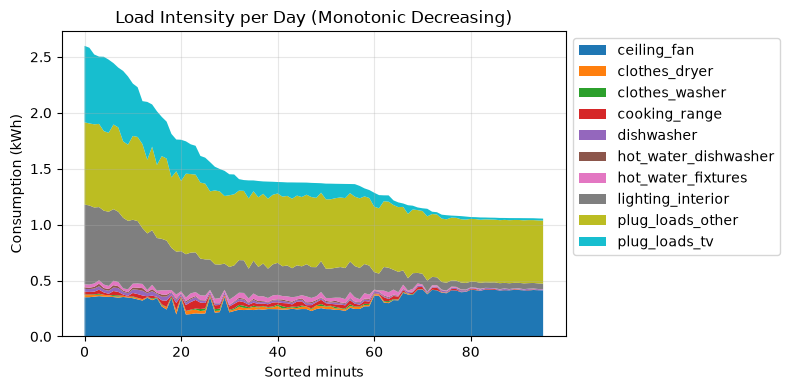

In [208]:
make_mono_plot(32)

6A

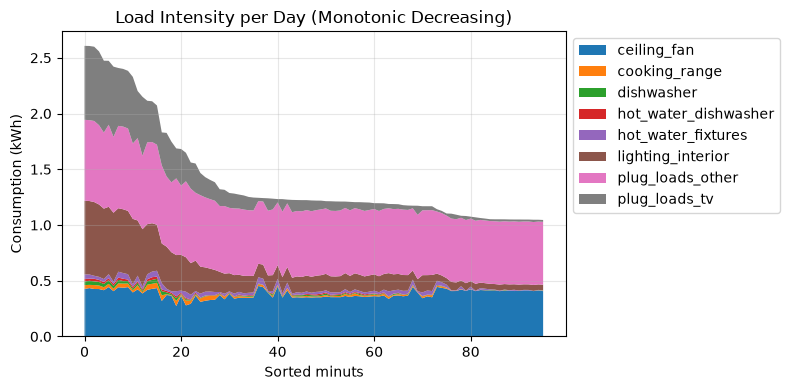

In [209]:
make_mono_plot(33)

In [210]:
make_mono_plot(34)

Aucune variable à tracer pour le dataframe 34


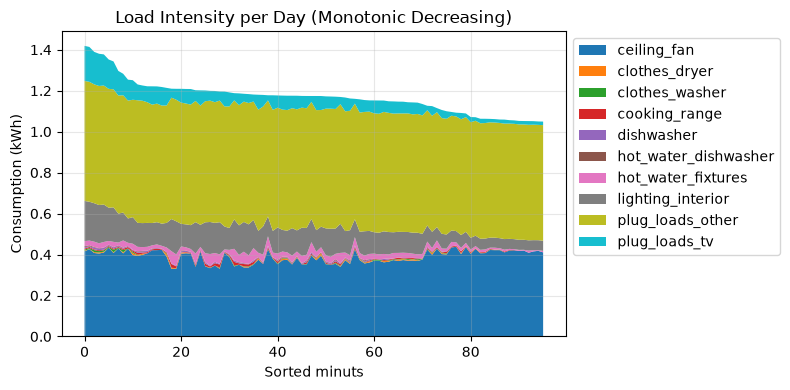

In [211]:
make_mono_plot(35)

6B

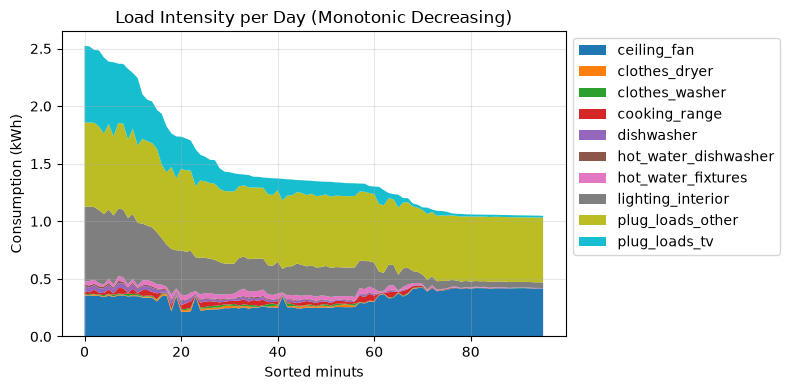

In [212]:
make_mono_plot(36)

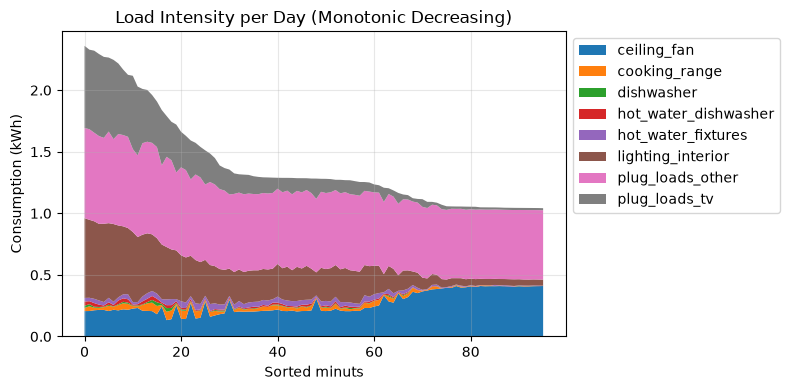

In [213]:
make_mono_plot(37)

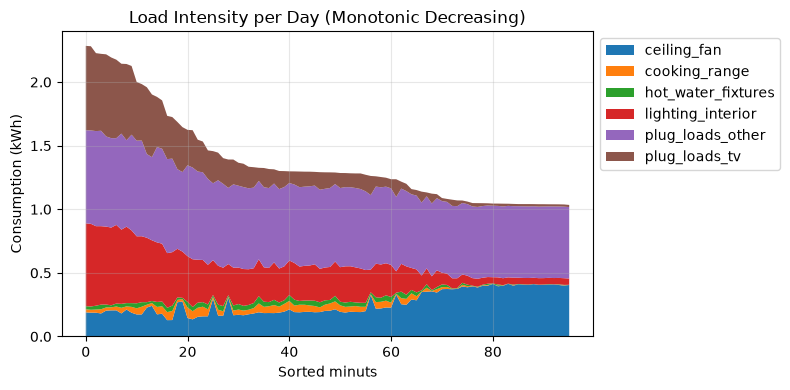

In [214]:
make_mono_plot(38)

7A

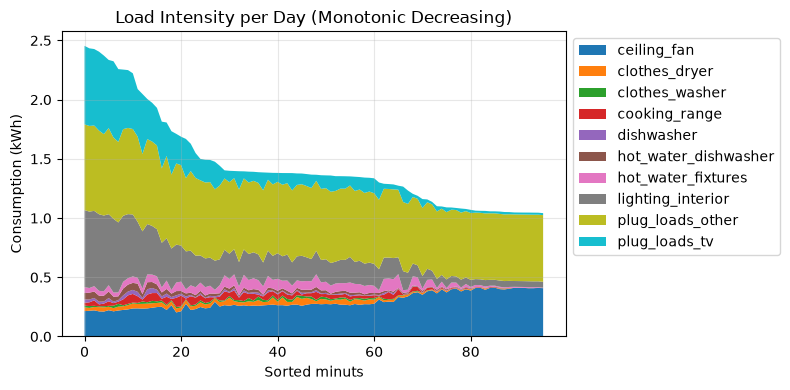

In [215]:
make_mono_plot(39)

In [216]:
make_mono_plot(40)

Aucune variable à tracer pour le dataframe 40


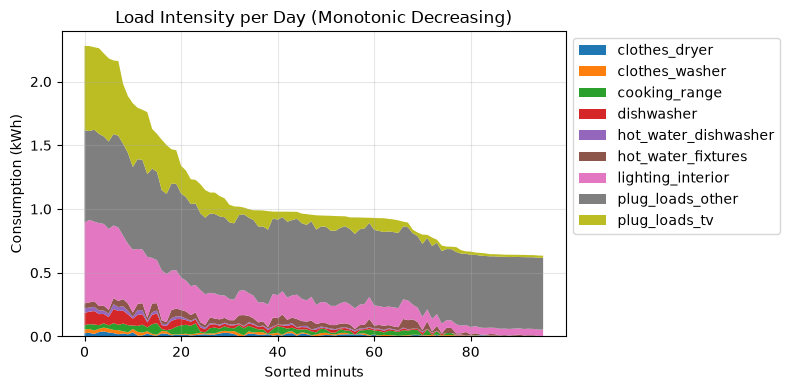

In [217]:
make_mono_plot(41)

7AK

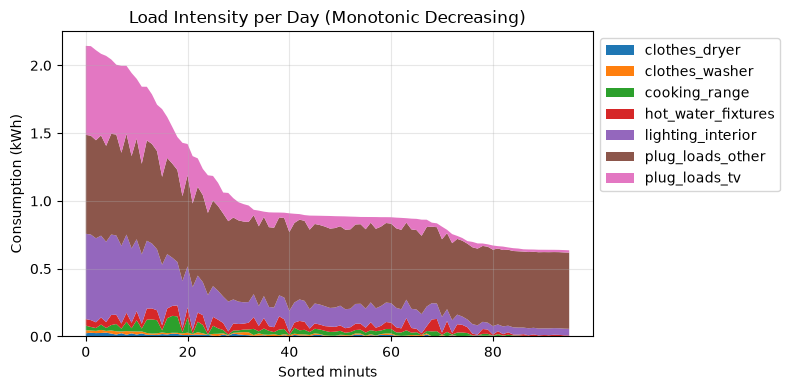

In [218]:
make_mono_plot(42)

In [219]:
make_mono_plot(43)

Aucune variable à tracer pour le dataframe 43


In [220]:
make_mono_plot(44)

Aucune variable à tracer pour le dataframe 44


7B

In [221]:
make_mono_plot(45)

Aucune variable à tracer pour le dataframe 45


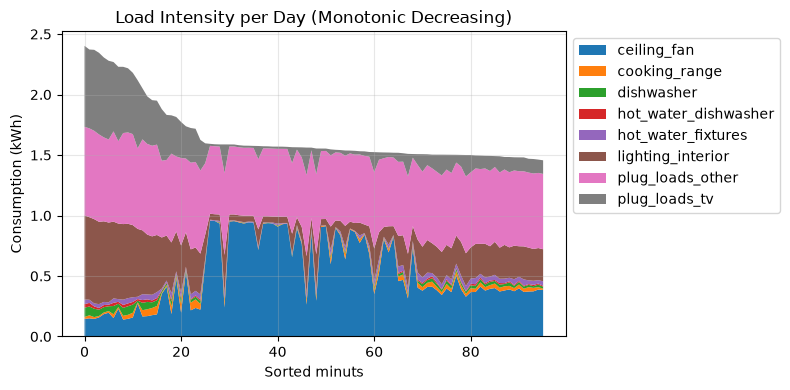

In [222]:
make_mono_plot(46)

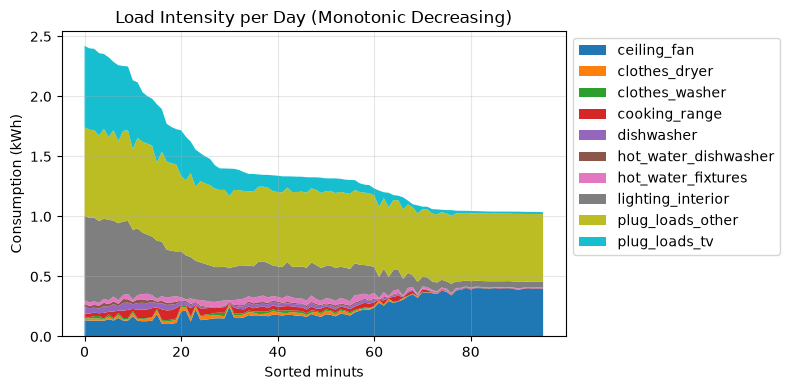

In [223]:
make_mono_plot(47)

### II. Corrélations entre variables de df_metadataF

Matrice /df de covariance au sein d'un bâtiment, entre différentes variables. 

Test sur le dataframe n°30 (zone 5B, froid et sec)

In [224]:
def correlate(index):
    pearson_corr = dataframes[index].drop(columns = ['timestamp', 'date', 'minute'])
    pearson_corr = pearson_corr.corr(method='pearson').fillna(0)
    print("Pearson Correlation:")
    return pearson_corr

corr30 = correlate(30)
corr30

Pearson Correlation:


,bldg_id,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,out.electricity.freezer.energy_consumption..kwh,...,out.schedules.lighting_interior,out.schedules.no_space_cooling,out.schedules.no_space_heating,out.schedules.occupants,out.schedules.peak_period,out.schedules.plug_loads_other,out.schedules.plug_loads_tv,out.schedules.power_outage,out.schedules.pre_peak_period,out.schedules.vacancy
bldg_id,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
in.sqft,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
out.electricity.ceiling_fan.energy_consumption..kwh,0.0,0.0,1.000000,-0.014730,-0.012837,0.396661,0.444419,-0.007998,0.0,0.0,...,-0.275933,0.0,0.0,-0.031648,0.0,-0.534964,-0.084216,0.0,0.0,0.0
out.electricity.clothes_dryer.energy_consumption..kwh,0.0,0.0,-0.014730,1.000000,0.017965,0.052892,0.055531,0.023212,0.0,0.0,...,0.107644,0.0,0.0,0.036141,0.0,0.069555,0.095192,0.0,0.0,0.0
out.electricity.clothes_washer.energy_consumption..kwh,0.0,0.0,-0.012837,0.017965,1.000000,0.049018,0.048361,0.045020,0.0,0.0,...,0.078680,0.0,0.0,0.027817,0.0,0.051526,0.066628,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
out.schedules.plug_loads_other,0.0,0.0,-0.534964,0.069555,0.051526,-0.141958,-0.147306,0.126250,0.0,0.0,...,0.782267,0.0,0.0,0.213208,0.0,1.000000,0.698847,0.0,0.0,0.0
out.schedules.plug_loads_tv,0.0,0.0,-0.084216,0.095192,0.066628,0.178856,0.206837,0.150531,0.0,0.0,...,0.928516,0.0,0.0,0.337966,0.0,0.698847,1.000000,0.0,0.0,0.0
out.schedules.power_outage,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
out.schedules.pre_peak_period,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0


Pearson Correlation:


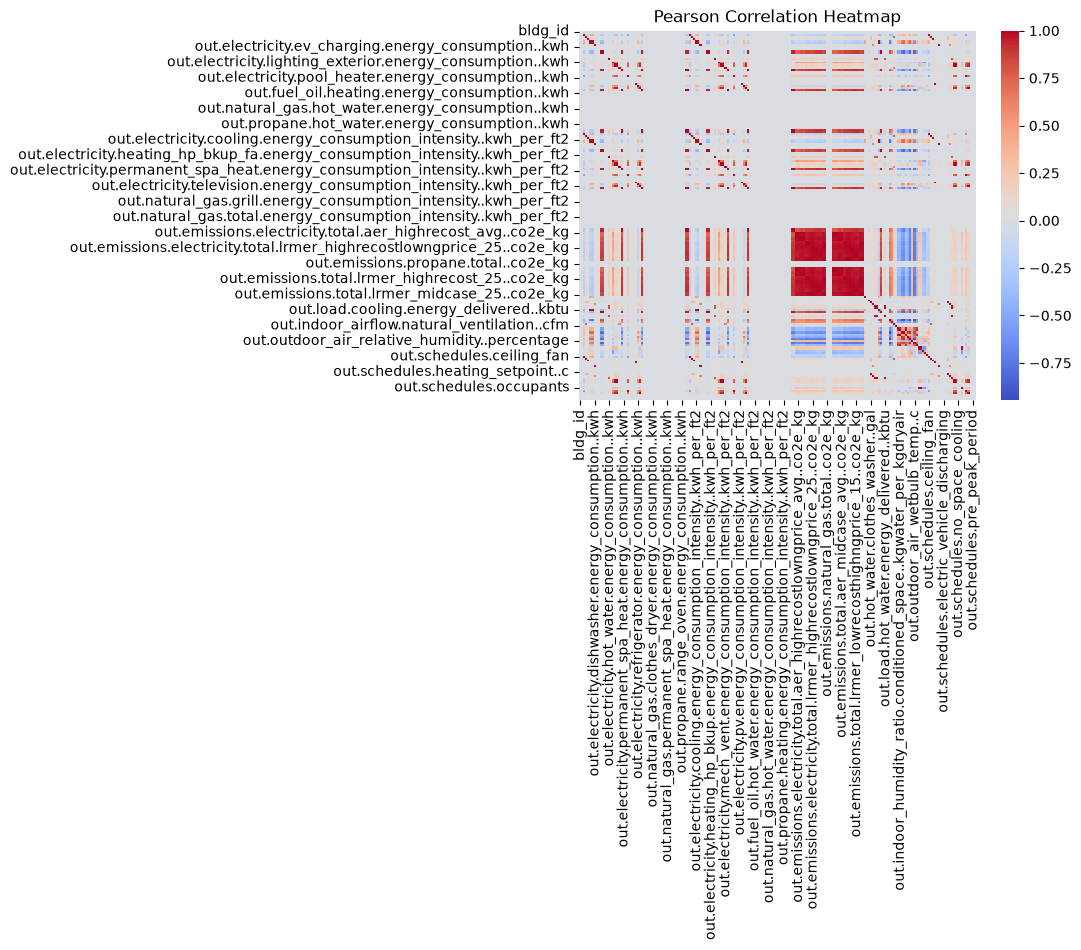

In [225]:
def correlation_plot(index):
    pearson_corr = correlate(index)
    sns.heatmap(pearson_corr, annot=False, cmap='coolwarm')
    plt.title("Pearson Correlation Heatmap")
    plt.show()
    return

correlation_plot(30)

In [226]:
corr_w_total = corr30["out.electricity.total.energy_consumption..kwh"].dropna()
corr_w_total

bldg_id                                                   0.000000
in.sqft                                                   0.000000
out.electricity.ceiling_fan.energy_consumption..kwh      -0.281310
out.electricity.clothes_dryer.energy_consumption..kwh     0.120133
out.electricity.clothes_washer.energy_consumption..kwh    0.020778
                                                            ...   
out.schedules.plug_loads_other                            0.248473
out.schedules.plug_loads_tv                               0.036673
out.schedules.power_outage                                0.000000
out.schedules.pre_peak_period                             0.000000
out.schedules.vacancy                                     0.000000
Name: out.electricity.total.energy_consumption..kwh, Length: 191, dtype: float64

In [227]:
corr_w_total_IMPORTANT1 = corr_w_total[corr_w_total >= 0.7]
corr_w_total_IMPORTANT2 = corr_w_total[corr_w_total<=-0.7]
corr_w_total_IMPORTANT = pd.concat([corr_w_total_IMPORTANT1,corr_w_total_IMPORTANT2],ignore_index=False)
print("Il y a "+str(corr_w_total_IMPORTANT.size)+" variables ayant une forte corrélation (VALEUR < -0.7 ou VALEUR > 0.7) avec la variable 'out.electricity.total.energy_consumption..kwh'.")
print("Ces variables sont : \n" + str(corr_w_total_IMPORTANT.index))

Il y a 47 variables ayant une forte corrélation (VALEUR < -0.7 ou VALEUR > 0.7) avec la variable 'out.electricity.total.energy_consumption..kwh'.
Ces variables sont : 
Index(['out.electricity.heating.energy_consumption..kwh',
       'out.electricity.heating_fans_pumps.energy_consumption..kwh',
       'out.electricity.net.energy_consumption..kwh',
       'out.electricity.total.energy_consumption..kwh',
       'out.site_energy.net.energy_consumption..kwh',
       'out.site_energy.total.energy_consumption..kwh',
       'out.electricity.heating.energy_consumption_intensity..kwh_per_ft2',
       'out.electricity.heating_fans_pumps.energy_consumption_intensity..kwh_per_ft2',
       'out.electricity.net.energy_consumption_intensity..kwh_per_ft2',
       'out.electricity.total.energy_consumption_intensity..kwh_per_ft2',
       'out.site_energy.net.energy_consumption_intensity..kwh_per_ft2',
       'out.site_energy.total.energy_consumption_intensity..kwh_per_ft2',
       'out.emissions.electric

In [299]:
df_metadataF["in.ashrae_iecc_climate_zone_2004"].loc[df_metadataF["bldg_id"]==412985]

412962    7AK
Name: in.ashrae_iecc_climate_zone_2004, dtype: str

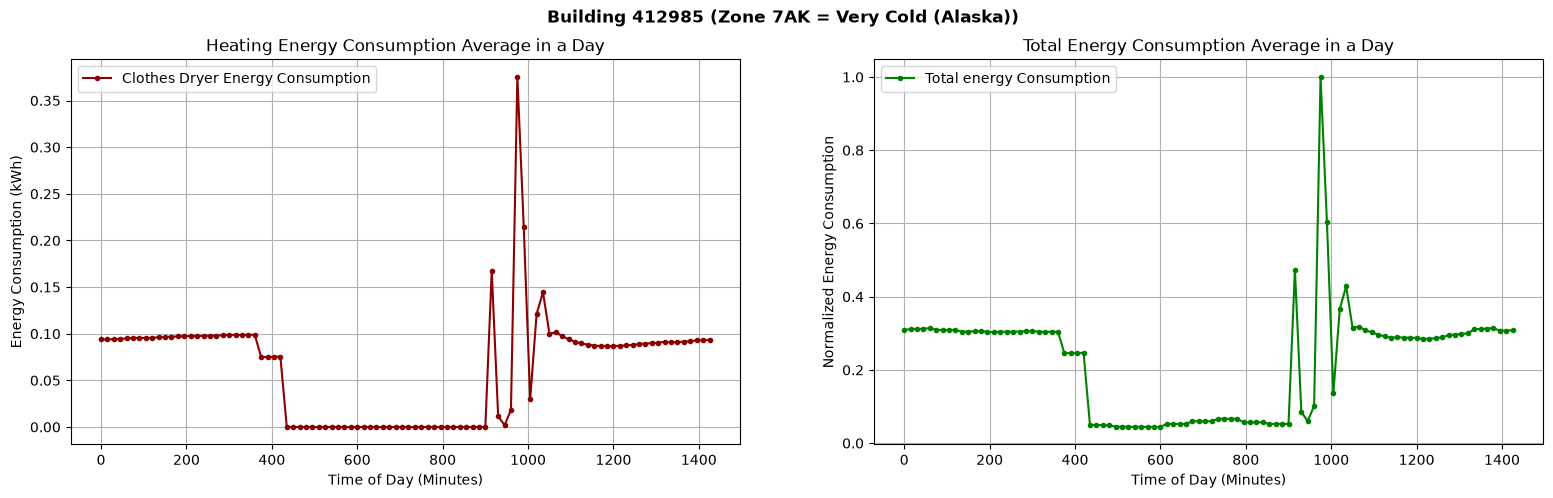

In [300]:
df_dryer_min = dataframes[43].groupby("minute")['out.electricity.heating.energy_consumption..kwh'].mean()
df_total_min = dataframes[43].groupby("minute")['out.electricity.total.energy_consumption..kwh'].mean()

fig, axis = plt.subplots(1, 2, figsize=(19, 5))

axis[0].plot(df_dryer_min.index, df_dryer_min.values, marker=".", color='darkred', label='Clothes Dryer Energy Consumption')
axis[0].set_title("Heating Energy Consumption Average in a Day")
axis[0].set_xlabel("Time of Day (Minutes)")
axis[0].set_ylabel("Energy Consumption (kWh)")
axis[0].grid(True)
axis[0].legend()

axis[1].plot(df_total_min.index, df_total_min.values/df_total_min.values.max(), marker='.', color='green', label='Total energy Consumption')
axis[1].set_title("Total Energy Consumption Average in a Day")
axis[1].set_xlabel("Time of Day (Minutes)")
axis[1].set_ylabel("Normalized Energy Consumption")
axis[1].grid(True)
axis[1].legend()

plt.suptitle("Building 412985 (Zone 7AK = Very Cold (Alaska))", fontsize=12, fontweight='bold')
plt.show()

In [229]:
corr_w_total_MID = corr_w_total[0.4<=corr_w_total]
corr_w_total_MID1 = corr_w_total_MID[corr_w_total_MID<0.7]

corr_w_total_MID3=corr_w_total[corr_w_total<=-0.4]
corr_w_total_MID2 = corr_w_total_MID3[corr_w_total_MID3>-0.7]

corr_w_total_MID=pd.concat([corr_w_total_MID2,corr_w_total_MID1])

print("Il y a "+str(corr_w_total_MID.size)+" variables ayant une corrélation moyenne (-0.7 < VALEUR < -0.4 ou 0.4 < VALEUR < 0.7) avec la variable 'out.electricity.total.energy_consumption..kwh'.")
print("Ces variables sont : \n" + str(corr_w_total_MID.index))

Il y a 7 variables ayant une corrélation moyenne (-0.7 < VALEUR < -0.4 ou 0.4 < VALEUR < 0.7) avec la variable 'out.electricity.total.energy_consumption..kwh'.
Ces variables sont : 
Index(['out.indoor_dewpoint_temperature.conditioned_space..c',
       'out.indoor_humidity_ratio.conditioned_space..kgwater_per_kgdryair',
       'out.indoor_operative_temperature.conditioned_space..c',
       'out.indoor_relative_humidity.conditioned_space..percentage',
       'out.indoor_temperature.conditioned_space..c',
       'out.outdoor_humidity_ratio..kgwater_per_kgdryair',
       'out.indoor_airflow.infiltration..cfm'],
      dtype='str')


In [230]:
corr_w_total_LOW1 = corr_w_total[corr_w_total <0.4]
corr_w_total_LOW = corr_w_total_LOW1[corr_w_total>-0.4]
print("Il y a "+str(corr_w_total_LOW.size)+" variables ayant une faible corrélation (-0.4 < VALEUR < 0.4) avec la variable 'out.electricity.total.energy_consumption..kwh'.")
print("Ces variables sont : \n" + str(corr_w_total_LOW.index))

Il y a 137 variables ayant une faible corrélation (-0.4 < VALEUR < 0.4) avec la variable 'out.electricity.total.energy_consumption..kwh'.
Ces variables sont : 
Index(['bldg_id', 'in.sqft',
       'out.electricity.ceiling_fan.energy_consumption..kwh',
       'out.electricity.clothes_dryer.energy_consumption..kwh',
       'out.electricity.clothes_washer.energy_consumption..kwh',
       'out.electricity.cooling.energy_consumption..kwh',
       'out.electricity.cooling_fans_pumps.energy_consumption..kwh',
       'out.electricity.dishwasher.energy_consumption..kwh',
       'out.electricity.ev_charging.energy_consumption..kwh',
       'out.electricity.freezer.energy_consumption..kwh',
       ...
       'out.schedules.lighting_interior', 'out.schedules.no_space_cooling',
       'out.schedules.no_space_heating', 'out.schedules.occupants',
       'out.schedules.peak_period', 'out.schedules.plug_loads_other',
       'out.schedules.plug_loads_tv', 'out.schedules.power_outage',
       'out.schedul

In [231]:
corr_w_total_MID.size + corr_w_total_IMPORTANT.size + corr_w_total_LOW.size == len(corr_w_total)

True

Croisement de deux matrices de corrélation (30 et 31)

In [232]:
corr31 = correlate(31)
corr31

Pearson Correlation:


,bldg_id,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,out.electricity.freezer.energy_consumption..kwh,...,out.schedules.lighting_interior,out.schedules.no_space_cooling,out.schedules.no_space_heating,out.schedules.occupants,out.schedules.peak_period,out.schedules.plug_loads_other,out.schedules.plug_loads_tv,out.schedules.power_outage,out.schedules.pre_peak_period,out.schedules.vacancy
bldg_id,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
in.sqft,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
out.electricity.ceiling_fan.energy_consumption..kwh,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
out.electricity.clothes_dryer.energy_consumption..kwh,0.0,0.0,0.0,1.000000,0.020690,0.0,0.0,0.0,0.0,0.0,...,0.069605,0.0,0.0,0.023491,0.0,0.039106,0.050530,0.0,0.0,0.0
out.electricity.clothes_washer.energy_consumption..kwh,0.0,0.0,0.0,0.020690,1.000000,0.0,0.0,0.0,0.0,0.0,...,0.084555,0.0,0.0,0.029237,0.0,0.043987,0.058552,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
out.schedules.plug_loads_other,0.0,0.0,0.0,0.039106,0.043987,0.0,0.0,0.0,0.0,0.0,...,0.712587,0.0,0.0,0.084657,0.0,1.000000,0.623167,0.0,0.0,0.0
out.schedules.plug_loads_tv,0.0,0.0,0.0,0.050530,0.058552,0.0,0.0,0.0,0.0,0.0,...,0.882319,0.0,0.0,0.140213,0.0,0.623167,1.000000,0.0,0.0,0.0
out.schedules.power_outage,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0
out.schedules.pre_peak_period,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0


In [233]:
def score_correlation(corrA, corrB):
    mask = np.triu(np.ones(corrA.shape, dtype=bool), k=1)
    v1 = corrA.where(mask).stack()
    v2 = corrB.where(mask).stack()
    return v1.corr(v2)

# (le flotant renvoyé représente à quel point les 2 matrices évoluent de manière linéairement similaire)

In [234]:
score = score_correlation(corr30, corr31)
score

np.float64(0.8871376738730484)

In [235]:
def score_correlation_sans_var(corrA,corrB,variable : str):
    corrAbis = corrA.drop(columns=[variable],index=[variable])
    corrBbis = corrB.drop(columns=[variable],index=[variable])
    return score_correlation(corrAbis, corrBbis)

In [236]:
score_correlation(corr30,corr31)

np.float64(0.8871376738730484)

In [237]:
score_correlation_sans_var(corr30,corr31, "out.electricity.clothes_washer.energy_consumption..kwh")

np.float64(0.886917509612937)

In [238]:
def table_importance_variables(corrA,corrB):
    lignes = []
    colonnes = corrA.columns
    for i in range(len(colonnes)):
        variable = colonnes[i]
        score1 = score_correlation(corrA, corrB)
        score2 = score_correlation_sans_var(corrA, corrB, variable)
        ecart = abs(score1-score2)
        lignes.append({
            "Variable": variable,
            "Score de corr A/B": score1,
            "Score de corr A/B sans la variable": score2,
            "Ecart": ecart
        })
    return pd.DataFrame(lignes).sort_values("Ecart", ascending=False)


In [305]:
table_importance_variables(corr30,corr31)

,Variable,Score de corr A/B,Score de corr A/B sans la variable,Ecart
11,out.electricity.heating_fans_pumps.energy_cons...,0.887138,0.902396,0.015258
62,out.electricity.heating_fans_pumps.energy_cons...,0.887138,0.902396,0.015258
157,out.indoor_relative_humidity.conditioned_space...,0.887138,0.893314,0.006176
57,out.electricity.cooling_fans_pumps.energy_cons...,0.887138,0.891748,0.004611
6,out.electricity.cooling_fans_pumps.energy_cons...,0.887138,0.891748,0.004611
...,...,...,...,...
15,out.electricity.hot_water_solar_th.energy_cons...,0.887138,0.887071,0.000066
169,out.schedules.clothes_dryer,0.887138,0.887086,0.000051
54,out.electricity.clothes_dryer.energy_consumpti...,0.887138,0.887088,0.000050
3,out.electricity.clothes_dryer.energy_consumpti...,0.887138,0.887088,0.000050


In [301]:
def table_corr_absolues(corrA, corrB):
    lignes = []
    colonnes = corrA.columns
    for i in range(len(colonnes)):
        for j in range(i + 1, len(colonnes)):
            var1 = colonnes[i]
            var2 = colonnes[j]
            cA = corrA.loc[var1, var2]
            cB = corrB.loc[var1, var2]
            lignes.append({
                "Variable 1": var1,
                "Variable 2": var2,
                "Corr bâtiment A": cA,
                "Corr bâtiment B": cB,
                "Ecart": abs(cA - cB)
            })
    return pd.DataFrame(lignes).sort_values("Ecart")

In [302]:
table = table_corr_absolues(corr30, corr31)
table[table["Ecart"]>0]

,Variable 1,Variable 2,Corr bâtiment A,Corr bâtiment B,Ecart
3144,out.electricity.lighting_garage.energy_consump...,out.electricity.lighting_garage.energy_consump...,1.000000,1.000000,2.220446e-16
3489,out.electricity.mech_vent.energy_consumption..kwh,out.electricity.mech_vent.energy_consumption_i...,1.000000,1.000000,3.330669e-16
5154,out.electricity.television.energy_consumption....,out.electricity.television.energy_consumption_...,1.000000,1.000000,4.440892e-16
2619,out.electricity.hot_water.energy_consumption..kwh,out.electricity.hot_water.energy_consumption_i...,1.000000,1.000000,2.886580e-15
1905,out.electricity.heating.energy_consumption..kwh,out.electricity.heating.energy_consumption_int...,1.000000,1.000000,4.662937e-15
...,...,...,...,...,...
1175,out.electricity.cooling_fans_pumps.energy_cons...,out.electricity.cooling_fans_pumps.energy_cons...,1.000000,0.000000,1.000000e+00
2085,out.electricity.heating_fans_pumps.energy_cons...,out.electricity.heating_fans_pumps.energy_cons...,1.000000,0.000000,1.000000e+00
17516,out.indoor_operative_temperature.conditioned_s...,out.indoor_relative_humidity.conditioned_space...,0.428158,-0.605690,1.033848e+00
17550,out.indoor_radiant_temperature.conditioned_spa...,out.indoor_relative_humidity.conditioned_space...,0.467940,-0.576563,1.044503e+00


### III. Groupement manuel des variables les plus influentes sur la de corrélation entre bâtiments et comparaison avec les clusters par KNN

Fonction permetant de regroupper des bâtiments en fonction des varaibles les plus importantes

In [315]:
table_importance_variables(corr30,corr31)["Ecart"].head(10).sum()

np.float64(0.065893849936276)

In [314]:
table_importance_variables(corr30,corr30)["Ecart"].head(10).sum()

np.float64(2.220446049250313e-15)

In [322]:
def find_most_correlated(df, dataframes):
    tableau_comparaison = []
    df_corr = correlate(df)
    for e in dataframes:
        e_corr = correlate(e)
        somme = table_importance_variables(df_corr,e_corr)["Ecart"].head(10).sum()
        tableau_comparaison.append(somme)
    max = max(tableau_comparaison)
    for i in range(len(tableau_comparaison)):
        if tableau_comparaison[i]==max:
            return dataframes[i]

In [319]:
def paires(dataframes):
    dict = {}
    data = dataframes.copy()
    for e in dataframes:
        if data == []:
            dict[e]== []
        if e in data :
            best_df = find_most_correlated(e,data)
            dict[e]=[best_df]
            data.pop(best_df)
            data.pop(e)
    return dict

In [320]:
def groupes_de_4(dict):
    DICO = {i : [] for i in range(len(dict)/2+1)}
    nouvelles_paires = paires(dict.keys())
    TAB = []
    i=0
    while i <= len(nouvelles_paires):
        for cle, valeur in nouvelles_paires.items():
            if DICO[i]==[]:
                DICO[i].append(cle)
                DICO[i].append(valeur)
                del nouvelles_paires[cle]
        i+=1
    for cle, valeur in DICO.items():
            DICO[cle].append(dict[valeur][0])
            if len(valeur)==2:
                DICO[cle].append(dict[valeur][1])
    return DICO

In [ ]:
correlate()

In [324]:
groupes_de_4(paires(dataframes))

TypeError: list indices must be integers or slices, not DataFrame

### III. Différences et similitudes entre le bâtiment moyen de zones ASHRAE différentes

In [249]:
df_metadata.groupby("in.ashrae_iecc_climate_zone_2004").mean(numeric_only=True)
#par_etat = df_metadata.groupby('in.state', as_index=False).agg(nb=(CONSO_COL, 'count'),conso_moy=(CONSO_COL, 'mean')).sort_values('nb', ascending=False).head(20)

,bldg_id,upgrade,weight,applicability,in.sqft..ft2,in.representative_income,in.aiannh_area,in.bathroom_spot_vent_hour,in.bedrooms,in.clothes_dryer_usage_level,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
in.ashrae_iecc_climate_zone_2004,,,,,,,,,,,,,,,,,,,,,
1A,275131.423744,0.0,253.903673,1.0,1490.732217,86183.773438,0.003856,11.114155,2.483409,1.003044,...,0.033040,0.017369,0.054011,8.480225,8.750102,0.242009,0.602740,0.097378,1.261695,2.179097
2A,275980.366247,0.0,253.903673,1.0,1677.693929,77383.664062,0.005677,10.940153,2.775763,0.999275,...,0.046709,0.014433,0.106366,10.680764,10.701381,0.339460,0.755454,0.124685,2.583379,3.350627
2B,277383.943457,0.0,253.903673,1.0,1812.311907,79009.609375,0.00663,10.973570,2.841054,1.000424,...,0.034119,0.012119,0.058039,10.588064,10.769260,0.381251,0.471038,0.125251,2.912975,3.271572
3A,275285.895514,0.0,253.903673,1.0,1692.800456,72897.531250,0.083073,11.004892,2.828976,1.000599,...,0.074145,0.018047,0.402980,13.387066,13.394278,0.246389,0.491275,0.138856,2.031895,3.298072
3B,274750.884327,0.0,253.903673,1.0,1548.949923,91666.406250,0.003014,11.021780,2.648539,0.999076,...,0.065178,0.016863,0.154090,10.655740,10.882327,0.215358,0.288448,0.139107,1.765484,2.768341
3C,277001.096944,0.0,253.903673,1.0,1515.077943,136269.734375,0.000155,11.031177,2.597410,0.999100,...,0.073037,0.020057,0.176593,10.431785,10.612984,0.113231,0.179153,0.140148,1.106251,2.462463
4A,274800.808565,0.0,253.903673,1.0,1637.773164,89115.062500,0.001588,10.997771,2.688429,1.000225,...,0.077047,0.019511,0.561529,17.018915,17.039168,0.382845,0.275850,0.117033,0.964785,2.326003
4B,275480.514346,0.0,253.903673,1.0,1671.424271,69012.890625,0.009643,10.808796,2.821731,1.006820,...,0.302858,0.037185,1.338502,14.840714,14.979574,0.199906,0.298683,0.134757,1.912512,2.980950
4C,273693.332639,0.0,253.903673,1.0,1583.756439,95503.125000,0.016098,10.809533,2.703283,1.000189,...,0.098522,0.033014,0.330781,13.476229,13.497549,0.666035,0.268308,0.147365,1.120960,2.217740
